# La réplique des ETF NANC / GOP — §13.0 → §13.15

> **Volet extrait du notebook 11** (le dossier NANC/GOP) — cellules et **sorties figées** copiées
> telles quelles depuis le run original, le 2026-08-11. Le socle (données, prix, moteur —
> §1-§7) vit dans `noter_les_titres.ipynb` : ce volet n'est **pas ré-exécutable seul**.
> L'intégral d'origine : `_archive/11_Strategie_Ticker_integral_20260811.ipynb`
> (branche `presentation`).


## §13.0 — Récapitulatif : les trois répliques de produits réels (ce qui est appliqué)

Avant les mesures, voici **exactement ce qu'on applique** pour chaque produit, face à sa **règle publiée**.
Trois colonnes : leur règle (source) · notre code · ce qui est **fidèle / approximé / non-divulgué**.

| réplique | leur règle (source) | ce qu'on applique (code) | fidèle · approximé · non-divulgué | validation |
|---|---|---|---|---|
| **NANC** (Dém.) | **ACHATS** (pas le net) sur **3 ans** à δ, pondéré au « **niveau de trading** » (gros **+ récurrents + de plusieurs élus**), 100-200 titres, ~8,5 % max *(prospectus lu p.2)* | `poids_parti("Democrat")` : $(\sum \text{achats})\times(\text{nb élus})$, fusion classes d'actions, **cap 8,5 %**, 3 ans δ | **fidèle** : achats · breadth · cap · 3 ans · δ. **non modélisé** : « en poste » ; **formule exacte non divulguée** (qualitative) | **recouvrement 5/10** vs vrai NANC (NVDA 8,5 % **exact**, GOOG/MSFT/AMZN/AAPL) ; excès **+2,98 %/an** ≈ réel **+2,67 %** |
| **GOP** (Rép.) | idem, élus **Républicains** | `poids_parti("Republican")` | idem | excès +1,24 %/an ; *(holdings GOP réels non fournis → validé par symétrie de règle)* |
| **Quiver Congress Buys** | long des **achats**, **pondéré à la taille (\$)**, rebalancé **hebdo** *(page Quiver ; disclaimer « hypothetical »)* | `poids_taille(mode="dollar", W=63)` : $w\propto\sum\$$ sur 63 j ; `run_livre` **hebdo** *et* mensuel ; à **τ et δ** | **fidèle** : long · \$-pond · hebdo. **non divulgué (choisi)** : fenêtre 63 j, règle de sortie, τ vs δ | β 1,06 ; leurs β/Sharpe ⇒ ~24 % *(§14.1)* |
| **Quiver Long-Short** | **+130 %** achats **−30 %** ventes, pondéré \$ *(panier short, fenêtre, timing : non divulgués)* | `longshort` : $1{,}3\,r_{\text{long}}-0{,}3\,r_{\text{short}}$ ; short $=$ **toutes les ventes** \$-pond 63 j **(notre choix)** ; overlay rebalancé quotidien | **fidèle** : 130/30 ; **non divulgué** : le panier short (test de sensibilité §14.0) | β 1,07 ; les 2 jambes $\approx$ marché $\Rightarrow$ **LS $\approx$ marché levé** |

Détail et mesures : **§13** (NANC/GOP) · **§14** (Quiver, dont §14.1 « on fait bien ? »).

## §13 — Ce que font les produits réels : réplique NANC / GOP (corrigée sur prospectus)

Les ETF **NANC** (Dém.) / **GOP** (Rép.) de Subversive/Unusual Whales. **Règle EXACTE** (prospectus lu, p.2) :
- univers = titres **achetés** par les élus d'un parti (+ famille), PTR, **en poste**, sur **3 ans** glissants ;
- pondéré au « **niveau de trading** » : **gros achats + récurrents + de plusieurs élus** → surpondérés ;
- ⚠️ **les ventes de positions détenues AVANT la fenêtre / avant l'entrée en fonction ne réduisent PAS** le portefeuille ;
- **100-200 titres**, rebalancé **à la divulgation** ($\delta$) ; concentration observée **~8,5 % max**.

**Correction (Alice, holdings réels 24/07/2026).** Notre 1re version pondérait au **net brut** (achats − *toutes*
les ventes) : le netting rendait MSFT/AAPL/AMZN **négatifs** (élus vendant de vieilles positions) et les
**excluait** → recouvrement **2/10** avec le vrai NANC. Le prospectus dit justement de **ne pas** soustraire ces
ventes. On corrige : pondération aux **achats $\times$ nombre d'élus**, **top-150** (queue de-minimis coupée), **cap 8,5 %**.

$$w^{P}_{i,t} \;\propto\; \Big(\textstyle\sum_{k\,:\,\text{parti }P,\ \text{achat},\ t-3\text{ans}<\delta_k\le t} A_k\Big)\ \times\ \#\{\text{élus de }P\text{ acheteurs de } i\},\qquad \text{puis plafonné à } 8{,}5\%\quad(P=\text{NANC/GOP})$$

In [67]:
# arrays de fenêtrage sur la DIVULGATION (δ), persistants pour le §13
ordre_d = np.argsort(df.ide.values, kind="stable")
I_de    = df.ide.values[ordre_d]
W3 = 756                                                       # ~3 ans de bourse

def cap_poids(w, cap=0.085):
    # plafonne chaque poids à `cap`, redistribue l'excédent au prorata (diversification ~ vrai NANC)
    w = w.astype(float).copy()
    for _ in range(200):
        over = w > cap + 1e-12
        if not over.any(): break
        exces = float((w[over] - cap).sum()); w[over] = cap
        low = w < cap - 1e-12
        if not low.any() or w[low].sum() <= 0: break
        w[low] += exces * w[low] / w[low].sum()
    return w / w.sum()

FUSION = {"GOOGL": "GOOG", "BRK-A": "BRK-B", "FOXA": "FOX", "NWSA": "NWS"}   # classes d'actions = une société

def poids_parti(i1, parti, topN=150, cap=0.085):
    # parti = "Democrat" (→ ETF NANC) ou "Republican" (→ ETF GOP) — MÊME règle pour les deux (V1).
    # prospectus : « niveau de trading » des ACHATS (les ventes de vieilles positions ne comptent PAS, ≠ net brut) ;
    #   gros + récurrents + de PLUSIEURS élus surpondérés → score = (Σ achats) × (nb d'élus acheteurs).
    # + fusion des classes d'actions, top-N (100-200), cap de position 8,5 % (diversification observée), sur 3 ans de δ.
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[(g.party == parti) & (g.op == "buy")]
    if not len(g): return {}
    g       = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)))
    buy     = g.groupby("tkm").A.sum()
    breadth = g.groupby("tkm").bioguide_id.nunique()
    score   = (buy * breadth.reindex(buy.index)).dropna()       # taille × nombre d'élus acheteurs
    score   = score[[tk for tk in score.index if tk in PXV and np.isfinite(PXV[tk][i1+1]) and vivant(tk, i1)]]
    score   = score.sort_values(ascending=False).head(topN)     # les ~150 plus « tradés » (de-minimis ≈ queue coupée)
    if score.sum() <= 0: return {}
    return cap_poids(score / score.sum(), cap).to_dict()

WP_nanc = {i: poids_parti(i, "Democrat")   for i in coupes[:-1]}
WP_gop  = {i: poids_parti(i, "Republican") for i in coupes[:-1]}
span_nanc, _ = run_livre(WP_nanc, np.inf)
span_gop,  _ = run_livre(WP_gop,  np.inf)
nN = int(np.median([len(WP_nanc[i]) for i in coupes[:-1] if WP_nanc[i]]))
nG = int(np.median([len(WP_gop[i])  for i in coupes[:-1] if WP_gop[i]]))
print(f"nb de titres détenus (médiane) — NANC {nN} · GOP {nG}  (le prospectus dit 100-200)")
pd.DataFrame([bilan(span_nanc, "réplique NANC (Démocrates)"),
             bilan(span_gop,  "réplique GOP (Républicains)"),
             bilan(spanD,     "notre base à δ (rappel)")]).set_index("run").round(3)

nb de titres détenus (médiane) — NANC 150 · GOP 150  (le prospectus dit 100-200)


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
réplique NANC (Démocrates),2.980,1.470,1.257,1.064,1.077,672.348,9/13
réplique GOP (Républicains),1.236,1.621,1.117,1.080,1.004,612.246,10/13
notre base à δ (rappel),0.350,0.183,-0.032,-0.019,1.010,530.210,7/13


In [68]:
# VALIDATION contre les HOLDINGS RÉELS de NANC (fichier fourni par Alice, 24/07/2026)
real = pd.read_csv(f"{RACINE}/02_recherche_backtest/cache/NANC_holdings_20260724.csv")
real = real[~real.StockTicker.isin(["Cash&Other", "FGXXX"])].copy()
real["w"] = real.Weightings.str.rstrip("%").astype(float)
real = real.sort_values("w", ascending=False).reset_index(drop=True)
rep  = (pd.Series(poids_parti(coupes[-2], "Democrat")).sort_values(ascending=False) * 100)
def recouvre(n): return len(set(rep.head(n).index) & set(real.head(n).StockTicker))
nvda_r = float(real.set_index("StockTicker").w.get("NVDA", np.nan))
print(f"Recouvrement réplique ↔ vrai NANC : top-10 {recouvre(10)}/10 · top-15 {recouvre(15)}/15 · top-20 {recouvre(20)}/20")
print(f"NVDA — réplique {rep.get('NVDA', 0):.1f} % vs réel {nvda_r:.1f} %  ·  titres réplique {len(rep)} · plus gros {rep.max():.1f} %")
print("(rappel : la 1re version pondérée au net-$ donnait 2/10 et NVDA 25 %)\n")
cmp = pd.DataFrame({
    "vrai NANC":      [f"{t} {w:.1f}%" for t, w in real.head(15)[["StockTicker", "w"]].values],
    "notre réplique": [f"{t} {w:.1f}%" for t, w in zip(rep.head(15).index, rep.head(15).values)]})
cmp.index = range(1, 16)
display(cmp)

Recouvrement réplique ↔ vrai NANC : top-10 5/10 · top-15 7/15 · top-20 10/20
NVDA — réplique 8.5 % vs réel 8.5 %  ·  titres réplique 150 · plus gros 8.5 %
(rappel : la 1re version pondérée au net-$ donnait 2/10 et NVDA 25 %)



,vrai NANC,notre réplique
1,NVDA 8.5%,NVDA 8.5%
2,GOOG 5.8%,GOOG 8.5%
3,MSFT 5.3%,AMZN 8.2%
4,AMAT 5.2%,MSFT 8.2%
5,AMZN 4.7%,AAPL 6.6%
6,AAPL 4.6%,AVGO 6.3%
7,CRWD 3.4%,PANW 5.4%
8,PM 3.2%,META 3.4%
9,AXP 2.8%,TSM 1.5%
10,LLY 2.7%,NFLX 1.4%


corrélation des poids ρ = 0.73  ·  exposition commune Σ min(wʳᵉᵉˡ, wʳᵉᵖ) = 51 %  ·  recouvrement top-15 7/15


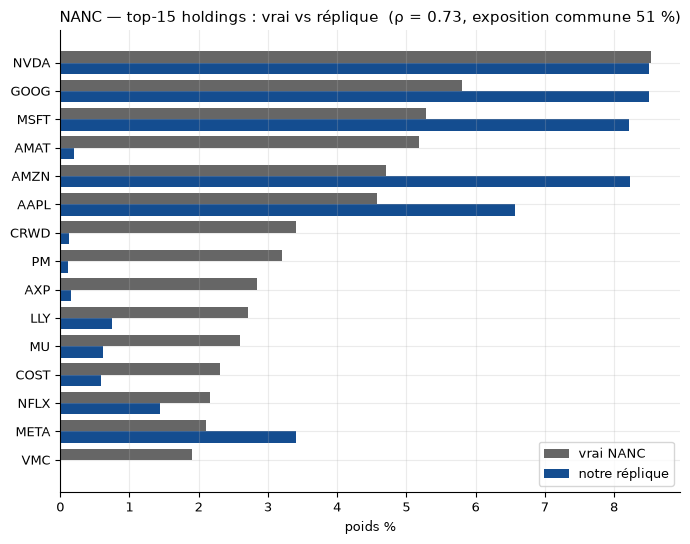

In [69]:
# MÉTRIQUES de fidélité + FIGURE de comparaison (vrai NANC vs réplique)
FUS   = {"GOOGL": "GOOG", "BRK-A": "BRK-B", "FOXA": "FOX", "NWSA": "NWS"}
realw = real.assign(tk=real.StockTicker.map(lambda t: FUS.get(t, t))).groupby("tk").w.sum()
M     = pd.DataFrame({"reel": realw, "rep": rep.groupby(rep.index.map(lambda t: FUS.get(t, t))).sum()}).fillna(0.0)
rho     = M[(M.reel > 0) | (M.rep > 0)].corr().iloc[0, 1]        # corrélation des poids réel↔réplique
commune = float(M[["reel", "rep"]].min(axis=1).sum())           # exposition commune = Σ min(w_réel, w_rép)
print(f"corrélation des poids ρ = {rho:.2f}  ·  exposition commune Σ min(wʳᵉᵉˡ, wʳᵉᵖ) = {commune:.0f} %  "
      f"·  recouvrement top-15 {recouvre(15)}/15")
top = M.sort_values("reel", ascending=False).head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6)); yy = np.arange(len(top)); h = 0.4
ax.barh(yy + h/2, top.reel, h, color=GRIS, label="vrai NANC")
ax.barh(yy - h/2, top.rep,  h, color=BLEU, label="notre réplique")
ax.set_yticks(yy); ax.set_yticklabels(top.index, fontsize=9); ax.set_xlabel("poids %"); ax.legend()
ax.set_title(f"NANC — top-15 holdings : vrai vs réplique  (ρ = {rho:.2f}, exposition commune {commune:.0f} %)")
plt.savefig(f"{FIGS}/nanc_compare.png", dpi=150, bbox_inches="tight"); plt.show()

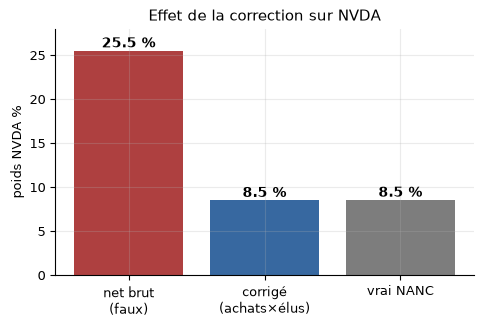

In [70]:
# FIGURE : l'effet de la correction sur NVDA (le plus gros nom) — net brut → corrigé → réel
fig, ax = plt.subplots(figsize=(5.4, 3.2))
vals = [25.5, rep.get("NVDA", 0.0), nvda_r]
labs = ["net brut\n(faux)", "corrigé\n(achats×élus)", "vrai NANC"]
ax.bar(labs, vals, color=[ROUGE, BLEU, GRIS], alpha=.85)
for i, v in enumerate(vals): ax.text(i, v + 0.4, f"{v:.1f} %", ha="center", fontweight="bold", fontsize=10)
ax.set_ylabel("poids NVDA %"); ax.set_ylim(0, 28); ax.set_title("Effet de la correction sur NVDA")
plt.savefig(f"{FIGS}/nanc_fix.png", dpi=150, bbox_inches="tight"); plt.show()

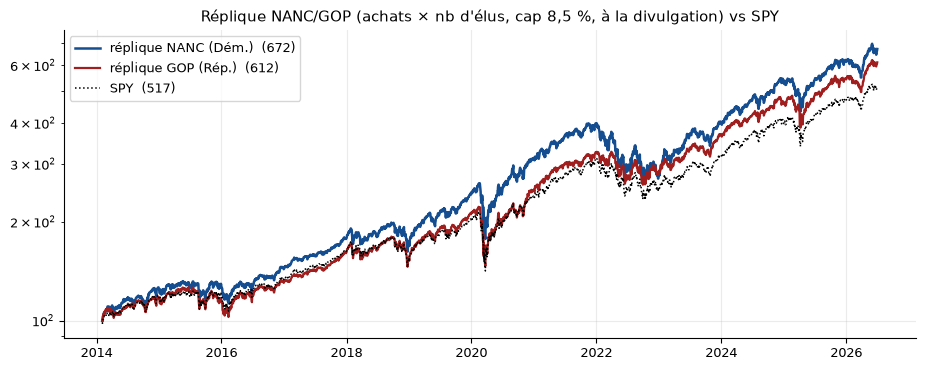

In [71]:
navspyN = (1 + r_spy.reindex(span_nanc.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(span_nanc.index, span_nanc, color=BLEU, lw=1.8, label=f"réplique NANC (Dém.)  ({span_nanc.iloc[-1]:.0f})")
ax.plot(span_gop.index,  span_gop,  color=ROUGE, lw=1.6, label=f"réplique GOP (Rép.)  ({span_gop.iloc[-1]:.0f})")
ax.plot(navspyN.index, navspyN, color="k", lw=1.1, ls=":", label=f"SPY  ({navspyN.iloc[-1]:.0f})")
ax.set_yscale("log"); ax.legend()
ax.set_title("Réplique NANC/GOP (achats × nb d'élus, cap 8,5 %, à la divulgation) vs SPY")
plt.savefig(f"{FIGS}/nanc_gop.png", dpi=150, bbox_inches="tight"); plt.show()

**Rendement TOTAL vs excès.** Le tableau ci-dessus donne l'\emph{excès} (rendement $-$ SPY), pas le total.
On montre ici le **rendement total annualisé** (ce qu'annoncent NANC/GOP) sur 2014-2026 ET sur la seule
fenêtre 2023-2026 (celle de leur historique réel) — pour lever la confusion « 0,2 % vs 22 % ».

In [72]:
spy_nav = (1 + r_spy.reindex(span_nanc.index).fillna(0)).cumprod() * 100
def cagr(s, i0=None):
    s = s.dropna()
    if i0 is not None: s = s[s.index >= i0]
    return (s.iloc[-1]/s.iloc[0])**(252/len(s)) - 1
d23 = pd.Timestamp("2023-02-01")
rows = []
for nom, s in [("réplique NANC", span_nanc), ("réplique GOP", span_gop), ("SPY", spy_nav)]:
    rows.append({"série": nom, "total/an 2014-26 %": 100*cagr(s), "total/an 2023-26 %": 100*cagr(s, d23)})
print("les vrais NANC/GOP : ~22 % (NANC) et ~17 % (GOP) /an depuis 2023 ; notre SPY ~21 %/an sur la même fenêtre")
pd.DataFrame(rows).set_index("série").round(1)

les vrais NANC/GOP : ~22 % (NANC) et ~17 % (GOP) /an depuis 2023 ; notre SPY ~21 %/an sur la même fenêtre


,total/an 2014-26 %,total/an 2023-26 %
série,,
réplique NANC,16.6,24.2
réplique GOP,15.8,22.5
SPY,14.4,20.8


### §13.1 — $\alpha$ et $\beta$ **glissants** (252 j) des répliques NANC/GOP

Le $\beta$ et l'$\alpha$ du bilan sont *plein-échantillon*. On les regarde ici **au fil du temps** (régression
OLS glissante sur 1 an) : $y_t=r_t-r_f$ régressé sur $x_t=r_{\text{SPY},t}-r_f$, $\ \hat\beta_t=\dfrac{\mathrm{cov}_W(y,x)}{\mathrm{var}_W(x)}$,
$\ \hat\alpha_t=(\bar y_W-\hat\beta_t\,\bar x_W)\times252$. Une cellule **valide** que ce glissant $=$ la régression `np.polyfit`.

NANC — β glissant méd 1.05 [0.96; 1.26] · α glissant méd +1.7 %/an
GOP  — β glissant méd 0.99 [0.89; 1.13] · α glissant méd +1.6 %/an


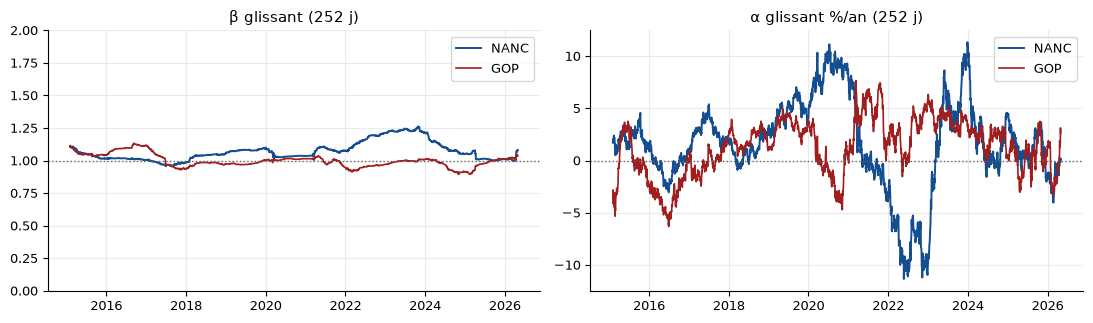

In [73]:
Wab = 252
def roll_ab(span):
    r = span.pct_change().dropna()
    d = pd.DataFrame({"y": r, "m": r_spy.reindex(r.index)}).join(ff[["RF"]]).dropna()
    y, x  = d.y - d.RF, d.m - d.RF
    beta  = y.rolling(Wab).cov(x) / x.rolling(Wab).var()
    alpha = (y.rolling(Wab).mean() - beta * x.rolling(Wab).mean()) * 252 * 100     # α annualisé, %
    return alpha.dropna(), beta.dropna(), y, x
aN, bN, yN, xN = roll_ab(span_nanc)
aG, bG, _, _   = roll_ab(span_gop)
print(f"NANC — β glissant méd {bN.median():.2f} [{bN.min():.2f}; {bN.max():.2f}] · α glissant méd {aN.median():+.1f} %/an")
print(f"GOP  — β glissant méd {bG.median():.2f} [{bG.min():.2f}; {bG.max():.2f}] · α glissant méd {aG.median():+.1f} %/an")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
ax[0].plot(bN.index, bN, color=BLEU, lw=1.4, label="NANC"); ax[0].plot(bG.index, bG, color=ROUGE, lw=1.2, label="GOP")
ax[0].axhline(1, color=GRIS, ls=":", lw=1); ax[0].set_ylim(0, 2); ax[0].set_title(f"β glissant ({Wab} j)"); ax[0].legend()
ax[1].plot(aN.index, aN, color=BLEU, lw=1.4, label="NANC"); ax[1].plot(aG.index, aG, color=ROUGE, lw=1.2, label="GOP")
ax[1].axhline(0, color=GRIS, ls=":", lw=1); ax[1].set_title(f"α glissant %/an ({Wab} j)"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{FIGS}/nanc_rolling.png", dpi=150, bbox_inches="tight"); plt.show()

In [74]:
# VALIDATION (règle : tout calcul ajouté est vérifié) — α/β glissants == régression OLS np.polyfit, même fenêtre
sl = slice(-Wab, None)
yy, xx = yN.values[sl], xN.values[sl]
b_pf, a_pf = np.polyfit(xx, yy, 1)                                   # la méthode du bilan (OLS)
b_roll = float(pd.Series(yy).cov(pd.Series(xx)) / pd.Series(xx).var())
a_roll = float(yy.mean() - b_roll * xx.mean())
print(f"dernière fenêtre — β : glissant {b_roll:.8f} vs polyfit {b_pf:.8f}  ·  α/j : glissant {a_roll:.3e} vs polyfit {a_pf:.3e}")
assert abs(b_roll - b_pf) < 1e-9 and abs(a_roll - a_pf) < 1e-9, "α/β glissants ≠ régression OLS"
b_full = float(np.polyfit(xN.values, yN.values, 1)[0])
print(f"✅ validation : α/β glissants = OLS (polyfit) à 1e-9 · β plein-échantillon {b_full:.2f} ≈ β bilan NANC 1,08")

dernière fenêtre — β : glissant 1.07978191 vs polyfit 1.07978191  ·  α/j : glissant -4.519e-06 vs polyfit -4.519e-06
✅ validation : α/β glissants = OLS (polyfit) à 1e-9 · β plein-échantillon 1.08 ≈ β bilan NANC 1,08


## §13.2 — Variante 2 : réplique **fidèle au prospectus** (netting $\gamma$ + de-minimis)

La variante 1 (§13, `poids_parti`) pondère les **achats seuls**. Le prospectus, lui, **nette** les achats contre les
**ventes récentes du même titre** — mais **ne** soustrait **pas** les ventes de positions acquises avant la fenêtre
(« will not adjust … for sales » de vieux lots). On l'implémente **sans toucher V1**, comme **V2 = `poids_parti_v2`**,
en **réutilisant la purge $\gamma$ du §4** (FIFO plein historique : une vente consomme les **plus vieux** lots d'abord) :

- **$\gamma_k$ à 3 ans** ($\bar a = 756$ j $=$ la fenêtre du prospectus, au lieu des 504 j du ticker) : part de la vente
  $k$ portant sur des lots détenus $\le 3$ ans. Une vente d'un lot dormant ($>3$ ans) a $\gamma_k\to 0$ $\Rightarrow$ **ignorée**.
- **Netting** par (élu $m$, titre $i$), sur la fenêtre 3 ans à $\delta$ : $\ \text{net}_{m,i}=\bigl[\sum_k A_k - \sum_k A_k\gamma_k\bigr]^{+}$
  (achats moins la part **récente** des ventes, plancher 0) ; $\ \text{net}_i=\sum_m \text{net}_{m,i}$.
- **Score** $s_i=\text{net}_i\times m_i$ ($m_i=\#$ élus avec net$>0$) — même forme que V1, mais sur le **net**.
- **De-minimis** : garder $i$ si $\text{net}_i\ge 1\%\cdot\sum_j\text{net}_j$ ; **cardinal borné à [100, 200]** (au lieu du top-150 fixe).
- **Cap 8,5 %** conservé (pour n'isoler que l'effet netting+sélection). ETF sectoriels : extension ultérieure.

Le $\gamma$ vend les vieux lots d'abord (bon sens FIFO) : ex. achat 10 M\$ il y a 4 ans (hors fenêtre) $+$ achat 5 M\$
il y a 1 an, vente 12 M\$ $\Rightarrow$ $\gamma_3=2/12$, net $=[5-12\cdot\tfrac{2}{12}]^{+}=$ **3 M\$** (l'ancien FIFO in-fenêtre
donnait 0). On calcule V1 **et** V2, on compare **recouvrement** aux vrais holdings NANC $+$ **bilan** ; on ne remplace
V1 **que si V2 fait mieux**.

In [75]:
# γ à 3 ANS (756 j) — MÊME FIFO plein historique que §3/§4, seuil = fenêtre du prospectus (≠ 504 du ticker).
# La purge γ vend les VIEUX lots d'abord : une vente d'un lot détenu >3 ans a γ3→0 (« acquis avant le lookback,
# n'ajuste pas le portefeuille » — prospectus) ; seule la part récente d'une vente réduit la position.
A_BAR3 = W3                                                    # 756 j de bourse ≈ 3 ans
gam3   = np.ones(len(df))
for idx, (pieces, reste) in VENTES.items():
    tot = sum(q for _, q in pieces) + reste
    if tot <= 0: continue
    jeune    = sum(q for h, q in pieces if h <= A_BAR3) + reste    # part détenue <= 3 ans (+ non apparié)
    gam3[idx] = jeune / tot
df["Aeff3"]   = df.A * np.where(df.op == "buy", 1.0, gam3)    # A (achat) · A·γ3 (vente : part récente)
df["signed3"] = df.Aeff3 * df.sgn                            # +A (achat) / −A·γ3 (vente récente)

def poids_parti_v2(i1, parti, cap=0.085, dm=0.01, nmin=100, nmax=200):
    # parti = "Democrat" (→ NANC) ou "Republican" (→ GOP) — MÊME règle pour les deux (V2).
    # FIDÈLE au prospectus via la purge γ (§4) : net = [Σ achats − Σ ventes·γ3]⁺ par (élu,titre) sur 3 ans (δ) ;
    #   score = net$ × nb d'élus, de-minimis 1%, 100-200 titres, cap 8,5% (comparabilité avec V1).
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[g.party == parti]                                # ACHATS + VENTES (on doit netter)
    if not len(g): return {}
    g   = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)))
    per = g.groupby(["bioguide_id", "tkm"]).signed3.sum()  # net brut par (élu,titre) = Σ achats − Σ ventes·γ3
    per = per[per > 0]                                     # plancher 0 par élu (pas de position négative)
    if not len(per): return {}
    neti = per.groupby("tkm").sum()                        # net agrégé par titre
    mi   = per.groupby("tkm").size()                       # nb d'élus à net positif
    neti = neti[[tk for tk in neti.index if tk in PXV and np.isfinite(PXV[tk][i1+1]) and vivant(tk, i1)]]
    if not len(neti): return {}
    theta = float(neti.sum())
    D     = neti[neti >= dm * theta]                       # de-minimis : net >= 1% du total tradé
    score = (neti * mi.reindex(neti.index)).dropna().sort_values(ascending=False)
    n     = int(np.clip(len(D), nmin, nmax))               # cardinal = |de-minimis|, borné [100,200]
    sel   = score.head(n)
    if sel.sum() <= 0: return {}
    return cap_poids(sel / sel.sum(), cap).to_dict()

WP_nanc2 = {i: poids_parti_v2(i, "Democrat")   for i in coupes[:-1]}
WP_gop2  = {i: poids_parti_v2(i, "Republican") for i in coupes[:-1]}
span_nanc2, _ = run_livre(WP_nanc2, np.inf)
span_gop2,  _ = run_livre(WP_gop2,  np.inf)
nN2 = int(np.median([len(WP_nanc2[i]) for i in coupes[:-1] if WP_nanc2[i]]))
nG2 = int(np.median([len(WP_gop2[i])  for i in coupes[:-1] if WP_gop2[i]]))
print(f"V2 nb de titres détenus (médiane) — NANC {nN2} · GOP {nG2}  (prospectus : 100-200)")
pd.DataFrame([bilan(span_nanc,  "V1 NANC — achats seuls"),
             bilan(span_nanc2, "V2 NANC — net γ 3 ans + de-minimis"),
             bilan(span_gop,   "V1 GOP — achats seuls"),
             bilan(span_gop2,  "V2 GOP — net γ 3 ans + de-minimis")]).set_index("run").round(3)

V2 nb de titres détenus (médiane) — NANC 100 · GOP 100  (prospectus : 100-200)


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
V1 NANC — achats seuls,2.980,1.470,1.257,1.064,1.077,672.348,9/13
V2 NANC — net γ 3 ans + de-minimis,1.403,0.734,-0.498,-0.353,1.080,557.996,9/13
V1 GOP — achats seuls,1.236,1.621,1.117,1.080,1.004,612.246,10/13
V2 GOP — net γ 3 ans + de-minimis,1.340,1.413,1.150,0.890,1.008,616.603,9/13


In [76]:
# FIDÉLITÉ vs vrais holdings NANC (real/rep déjà chargés au §13) — V1 vs V2, MÊME métrique
rep2  = (pd.Series(poids_parti_v2(coupes[-2], "Democrat")).sort_values(ascending=False) * 100)
realw = real.assign(tk=real.StockTicker.map(lambda t: FUSION.get(t, t))).groupby("tk").w.sum()
def _rec(rp, n): return len(set(rp.head(n).index) & set(real.head(n).StockTicker))
def _fid(rp):
    rpg = rp.groupby(rp.index.map(lambda t: FUSION.get(t, t))).sum()
    Mx  = pd.DataFrame({"reel": realw, "rep": rpg}).fillna(0.0)
    rho = Mx[(Mx.reel > 0) | (Mx.rep > 0)].corr().iloc[0, 1]
    return rho, float(Mx[["reel", "rep"]].min(axis=1).sum())
rho1, com1 = _fid(rep); rho2, com2 = _fid(rep2)
print("Fidélité aux vrais holdings NANC (coupe récente) :")
print(f"  V1 achats seuls          : top-10 {_rec(rep,10)}/10 · top-15 {_rec(rep,15)}/15 · top-20 {_rec(rep,20)}/20 "
      f"· ρ {rho1:.2f} · expo commune {com1:.0f}% · {len(rep)} titres · NVDA {rep.get('NVDA',0):.1f}%")
print(f"  V2 net γ 3 ans + de-min.  : top-10 {_rec(rep2,10)}/10 · top-15 {_rec(rep2,15)}/15 · top-20 {_rec(rep2,20)}/20 "
      f"· ρ {rho2:.2f} · expo commune {com2:.0f}% · {len(rep2)} titres · NVDA {rep2.get('NVDA',0):.1f}%")
cmp2 = pd.DataFrame({
    "vrai NANC": [f"{t} {w:.1f}%" for t, w in real.head(15)[["StockTicker","w"]].values],
    "V1 achats": [f"{t} {w:.1f}%" for t, w in zip(rep.head(15).index,  rep.head(15).values)],
    "V2 net":    [f"{t} {w:.1f}%" for t, w in zip(rep2.head(15).index, rep2.head(15).values)]})
cmp2.index = range(1, 16); display(cmp2)

Fidélité aux vrais holdings NANC (coupe récente) :
  V1 achats seuls          : top-10 5/10 · top-15 7/15 · top-20 10/20 · ρ 0.73 · expo commune 51% · 150 titres · NVDA 8.5%
  V2 net γ 3 ans + de-min.  : top-10 5/10 · top-15 9/15 · top-20 10/20 · ρ 0.67 · expo commune 48% · 100 titres · NVDA 8.5%


,vrai NANC,V1 achats,V2 net
1,NVDA 8.5%,NVDA 8.5%,NVDA 8.5%
2,GOOG 5.8%,GOOG 8.5%,AMZN 8.5%
3,MSFT 5.3%,AMZN 8.2%,MSFT 8.5%
4,AMAT 5.2%,MSFT 8.2%,AVGO 8.5%
5,AMZN 4.7%,AAPL 6.6%,GOOG 8.4%
6,AAPL 4.6%,AVGO 6.3%,PANW 8.1%
7,CRWD 3.4%,PANW 5.4%,META 6.0%
8,PM 3.2%,META 3.4%,AAPL 5.8%
9,AXP 2.8%,TSM 1.5%,TSM 3.5%
10,LLY 2.7%,NFLX 1.4%,NFLX 2.1%


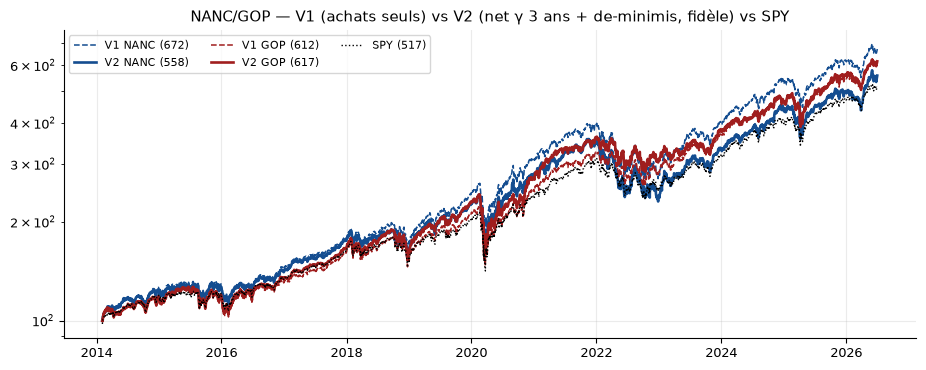

✅ V2 : γ3 = recalcul manuel (à 1e-12) · exemple net = 3 M$ (attendu 3) · Σw = 1 · poids ≤ 8,5 %
non-régression — γ@504 intact · V1 NANC NAV 672 · GOP NAV 612


In [77]:
# FIGURE NAV V1 vs V2 vs SPY + VALIDATION (Σw=1, poids <= cap) + non-régression V1
navspy2 = (1 + r_spy.reindex(span_nanc2.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(span_nanc.index,  span_nanc,  color=BLEU, lw=1.1, ls="--", label=f"V1 NANC ({span_nanc.iloc[-1]:.0f})")
ax.plot(span_nanc2.index, span_nanc2, color=BLEU, lw=1.9,          label=f"V2 NANC ({span_nanc2.iloc[-1]:.0f})")
ax.plot(span_gop.index,   span_gop,   color=ROUGE, lw=1.1, ls="--", label=f"V1 GOP ({span_gop.iloc[-1]:.0f})")
ax.plot(span_gop2.index,  span_gop2,  color=ROUGE, lw=1.9,          label=f"V2 GOP ({span_gop2.iloc[-1]:.0f})")
ax.plot(navspy2.index, navspy2, color="k", lw=1.0, ls=":", label=f"SPY ({navspy2.iloc[-1]:.0f})")
ax.set_yscale("log"); ax.legend(ncol=3, fontsize=8)
ax.set_title("NANC/GOP — V1 (achats seuls) vs V2 (net γ 3 ans + de-minimis, fidèle) vs SPY")
plt.savefig(f"{FIGS}/nanc_v1v2.png", dpi=150, bbox_inches="tight"); plt.show()

# VALIDATION §13.2 (règle : tout calcul ajouté est vérifié)
# (a) γ3 recalculé À LA MAIN sur une vente réelle == gam3 (seuil 756 j)
idx_t = next(i for i, (p, r) in VENTES.items() if p)          # une vente avec lots appariés
p_, r_ = VENTES[idx_t]; tot_ = sum(q for _, q in p_) + r_
g3_hand = (sum(q for h, q in p_ if h <= A_BAR3) + r_) / tot_
assert abs(g3_hand - gam3[idx_t]) < 1e-12, "gam3 ≠ recalcul manuel"
# (b) l'exemple du plan : achats 10 (4 ans, hors fenêtre) + 5 (1 an), vente 12 → γ3=2/12, net=[5−12·γ3]⁺=3
net_ex = max(0.0, 5.0 - 12.0 * (2.0 / 12.0))
assert abs(net_ex - 3.0) < 1e-12, "exemple net ≠ 3"
# (c) Σw = 1 partout ; poids ≤ cap dès que faisable
nmin_cap, cap_ok, worst = int(np.ceil(1 / 0.085)), True, 0.0
for i in coupes[:-1]:
    w = poids_parti_v2(i, "Democrat")
    if not w: continue
    assert abs(sum(w.values()) - 1) < 1e-9, f"V2 Σw != 1 à {i}"
    if len(w) >= nmin_cap and max(w.values()) > 0.085 + 1e-9:
        cap_ok, worst = False, max(worst, max(w.values()))
assert cap_ok, f"V2 cap 8,5% non respecté malgré >= {nmin_cap} titres (max {worst:.3f})"
print(f"✅ V2 : γ3 = recalcul manuel (à 1e-12) · exemple net = {net_ex:.0f} M$ (attendu 3) · Σw = 1 · poids ≤ 8,5 %")
# (d) non-régression : γ@504 du ticker et les ancres V1 n'ont PAS bougé (V2 est additif)
assert abs(df.loc[idx_t, "gamma"] - (sum(q for h, q in p_ if h <= A_BAR) + r_) / tot_) < 1e-12, "γ@504 modifié !"
print(f"non-régression — γ@504 intact · V1 NANC NAV {span_nanc.iloc[-1]:.0f} · GOP NAV {span_gop.iloc[-1]:.0f}")
assert span_nanc.iloc[-1] > 100 and span_gop.iloc[-1] > 100, "V1 a bougé ?!"

### §13.3 — V2 **sans le cap 8,5 %** : la vraie diversification émerge-t-elle ?

Le cap 8,5 % est un **ajout maison** (hors prospectus, qui dit seulement « non-diversified »). On refait V2 en le
**retirant** (`cap=1.0` ; netting $\gamma$, de-minimis et [100,200] **conservés**) pour voir si le score $s_i=\text{net}_i\times m_i$
reproduit **seul** la décroissance **douce** du vrai NANC (NVDA 8,5 → GOOG 5,8 → MSFT 5,3…), ou s'il **explose au sommet**.
On mesure la concentration : poids du 1ᵉʳ, somme du top-5, **N effectif** $=1/\sum_i w_i^2$.

In [78]:
# V2 SANS cap (cap=1.0 => cap_poids ne coupe rien) — de-minimis et [100,200] conservés
WP_nanc2nc = {i: poids_parti_v2(i, "Democrat",   cap=1.0) for i in coupes[:-1]}
WP_gop2nc  = {i: poids_parti_v2(i, "Republican", cap=1.0) for i in coupes[:-1]}
span_nanc2nc, _ = run_livre(WP_nanc2nc, np.inf)
span_gop2nc,  _ = run_livre(WP_gop2nc,  np.inf)
for i in coupes[:-1]:
    w = WP_nanc2nc[i]
    if w: assert abs(sum(w.values()) - 1) < 1e-9, f"sans-cap Σw != 1 à {i}"
pd.DataFrame([bilan(span_nanc2,   "V2 NANC — cap 8,5 %"),
             bilan(span_nanc2nc, "V2 NANC — SANS cap"),
             bilan(span_gop2,    "V2 GOP — cap 8,5 %"),
             bilan(span_gop2nc,  "V2 GOP — SANS cap")]).set_index("run").round(3)

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
"V2 NANC — cap 8,5 %",1.403,0.734,-0.498,-0.353,1.080,557.996,9/13
V2 NANC — SANS cap,2.585,1.075,0.806,0.374,1.087,621.792,8/13
"V2 GOP — cap 8,5 %",1.340,1.413,1.150,0.890,1.008,616.603,9/13
V2 GOP — SANS cap,2.291,2.413,2.090,1.392,1.000,679.534,9/13


In [79]:
# Concentration & fidélité : vrai NANC vs V2-cap vs V2-sans-cap (coupe récente)
rep2nc = (pd.Series(poids_parti_v2(coupes[-2], "Democrat", cap=1.0)).sort_values(ascending=False) * 100)
realpc = (real.assign(tk=real.StockTicker.map(lambda t: FUSION.get(t, t)))
              .groupby("tk").w.sum().sort_values(ascending=False))
def _conc(w):                                       # w en %, trié décroissant
    p = (w / w.sum()).values
    return w.iloc[0], w.head(5).sum(), 1 / np.sum(p**2)         # top-1, top-5, N effectif
print("Concentration (coupe récente) :")
for nom, w in [("vrai NANC", realpc), ("V2 cap 8,5%", rep2), ("V2 SANS cap", rep2nc)]:
    t1, t5, neff = _conc(w)
    print(f"  {nom:12s} — top-1 {t1:5.1f}% · top-5 {t5:5.1f}% · N effectif {neff:4.1f} · {len(w)} titres")
r_c, e_c   = _fid(rep2)
r_nc, e_nc = _fid(rep2nc)
print(f"\nfidélité vs vrai NANC — V2 cap : ρ {r_c:.2f} expo {e_c:.0f}%  ·  V2 SANS cap : ρ {r_nc:.2f} expo {e_nc:.0f}%")
cmp3 = pd.DataFrame({
    "vrai NANC":   [f"{t} {w:.1f}%" for t, w in zip(realpc.head(15).index, realpc.head(15).values)],
    "V2 cap":      [f"{t} {w:.1f}%" for t, w in zip(rep2.head(15).index,   rep2.head(15).values)],
    "V2 sans cap": [f"{t} {w:.1f}%" for t, w in zip(rep2nc.head(15).index, rep2nc.head(15).values)]})
cmp3.index = range(1, 16); display(cmp3)

Concentration (coupe récente) :
  vrai NANC    — top-1   8.5% · top-5  29.5% · N effectif 33.2 · 104 titres
  V2 cap 8,5%  — top-1   8.5% · top-5  42.4% · N effectif 18.9 · 100 titres
  V2 SANS cap  — top-1  37.0% · top-5  66.1% · N effectif  6.0 · 100 titres

fidélité vs vrai NANC — V2 cap : ρ 0.67 expo 48%  ·  V2 SANS cap : ρ 0.68 expo 41%


,vrai NANC,V2 cap,V2 sans cap
1,NVDA 8.5%,NVDA 8.5%,NVDA 37.0%
2,GOOG 5.8%,AMZN 8.5%,AMZN 10.7%
3,MSFT 5.3%,MSFT 8.5%,MSFT 7.5%
4,AMAT 5.2%,AVGO 8.5%,AVGO 6.1%
5,AMZN 4.7%,GOOG 8.4%,GOOG 4.9%
6,AAPL 4.6%,PANW 8.1%,PANW 4.8%
7,CRWD 3.4%,META 6.0%,META 3.5%
8,PM 3.2%,AAPL 5.8%,AAPL 3.4%
9,AXP 2.8%,TSM 3.5%,TSM 2.1%
10,LLY 2.7%,NFLX 2.1%,NFLX 1.2%


### §13.4 — Pourquoi notre portefeuille n'est PAS celui de NANC/GOP (les 2 fonds réels)

Alice : « même stratégie $\Rightarrow$ même portefeuille, non ? ». On confronte notre réplique **V2** aux **holdings
réels** des deux ETF (24/07/2026, `cache/{NANC,GOP}_holdings_20260724.csv`). Pour chaque position réelle : notre
poids vs le leur, le nombre d'élus et le \$ d'achats **dans NOS données** (fenêtre 3 ans), et l'**origine de l'écart** :
- **présent** : les achats existent chez nous $\Rightarrow$ l'écart est de la **pondération** ;
- **trou** : quasi aucun achat chez nous ($\#$élus $=0$ ou $<0{,}05$ M\$) $\Rightarrow$ **donnée manquante** ;
- **hors-univers** : pas de prix / privé / ETF / spin-off (SpaceX, IBIT, HONA…).

Attendu (diagnostic) : **NANC $\approx$ tout présent** (leurs poids ne suivent pas le flux 3 ans --- AMAT 5,2 \% avec
3 élus vs AVGO 1,2 \% avec 10) ; **GOP** a un vrai **trou** (FIX, leur \#1 à 8,4 \%) $+$ des noms **hors-univers**.

In [80]:
def real_holdings(f):
    r = pd.read_csv(f"{RACINE}/02_recherche_backtest/cache/{f}")
    r = r[~r.StockTicker.isin(["Cash&Other", "FGXXX"])].copy()
    r["w"] = r.Weightings.str.rstrip("%").astype(float)
    return r.sort_values("w", ascending=False).reset_index(drop=True)

real_gop = real_holdings("GOP_holdings_20260724.csv")
rep2_gop = (pd.Series(poids_parti_v2(coupes[-2], "Republican")).sort_values(ascending=False) * 100)
assert 95 < real.w.sum() < 101 and 95 < real_gop.w.sum() < 101, "somme poids réels ≠ ~100 %"

def diag(parti, rh, repw):
    # par position réelle : notre poids V2, #élus & $ d'achats chez nous (fenêtre 3 ans à la coupe récente), bucket
    i1 = coupes[-2]
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[(g.party == parti) & (g.op == "buy")].assign(tkm=lambda x: x.tk.map(lambda t: FUSION.get(t, t)))
    nb, dol, ntr = g.groupby("tkm").bioguide_id.nunique(), g.groupby("tkm").A.sum() / 1e6, g.groupby("tkm").size()
    rows = []
    for _, r in rh.iterrows():
        t   = FUSION.get(r.StockTicker, r.StockTicker)
        nel, dm, nt = int(nb.get(t, 0)), float(dol.get(t, 0.0)), int(ntr.get(t, 0))
        bucket = "hors-univers" if t not in PXV else ("trou" if (nel == 0 or dm < 0.05) else "présent")
        rows.append((r.StockTicker, round(r.w, 2), round(float(repw.get(t, 0.0)), 2), nel, round(dm, 2), nt, bucket))
    return pd.DataFrame(rows, columns=["ticker", "réel%", "notre%", "#élus", "$M", "#tr", "bucket"])

dN = diag("Democrat",   real,     rep2)
dG = diag("Republican", real_gop, rep2_gop)
for nom, d in [("NANC", dN), ("GOP", dG)]:
    part = d.groupby("bucket")["réel%"].sum().reindex(["présent", "trou", "hors-univers"]).fillna(0)
    print(f"{nom} — part du portefeuille réel par ORIGINE de l'écart : "
          f"présent/mal-pesé {part['présent']:.0f}% · trou de données {part['trou']:.0f}% · hors-univers {part['hors-univers']:.0f}%")
print("\nNANC — top-15 réel vs notre réplique V2 :"); display(dN.head(15))
print("GOP — top-15 réel vs notre réplique V2 :");  display(dG.head(15))

NANC — part du portefeuille réel par ORIGINE de l'écart : présent/mal-pesé 94% · trou de données 5% · hors-univers 1%
GOP — part du portefeuille réel par ORIGINE de l'écart : présent/mal-pesé 79% · trou de données 16% · hors-univers 5%

NANC — top-15 réel vs notre réplique V2 :


,ticker,réel%,notre%,#élus,$M,#tr,bucket
0,NVDA,8.53,8.50,16,16.68,99,présent
1,GOOG,5.81,8.39,16,3.83,88,présent
2,MSFT,5.29,8.50,14,3.49,88,présent
3,AMAT,5.19,0.28,3,0.41,21,présent
4,AMZN,4.70,8.50,13,3.77,93,présent
5,AAPL,4.58,5.80,13,3.00,73,présent
6,CRWD,3.41,0.00,3,0.25,25,présent
7,PM,3.20,0.00,2,0.32,25,présent
8,AXP,2.84,0.19,4,0.23,19,présent
9,LLY,2.71,0.41,10,0.45,35,présent


GOP — top-15 réel vs notre réplique V2 :


,ticker,réel%,notre%,#élus,$M,#tr,bucket
0,FIX,8.44,0.00,1,0.02,2,trou
1,INTC,5.51,0.24,8,1.35,30,présent
2,JPM,4.47,3.09,18,0.48,37,présent
3,NVDA,3.22,7.44,21,1.97,74,présent
4,ANET,3.22,0.00,7,0.62,18,présent
5,IBIT,3.00,0.00,0,0.00,0,hors-univers
6,AMD,2.95,2.45,13,1.07,40,présent
7,ALL,2.12,0.00,2,0.09,3,présent
8,UTHR,2.07,0.00,1,0.02,2,trou
9,ASML,1.98,0.27,5,0.46,25,présent


GOP (nouveau) — recouvrement top-10 3/10 · top-15 4/15 · ρ 0.11 · exposition commune 27%  (vs NANC ρ 0.67)


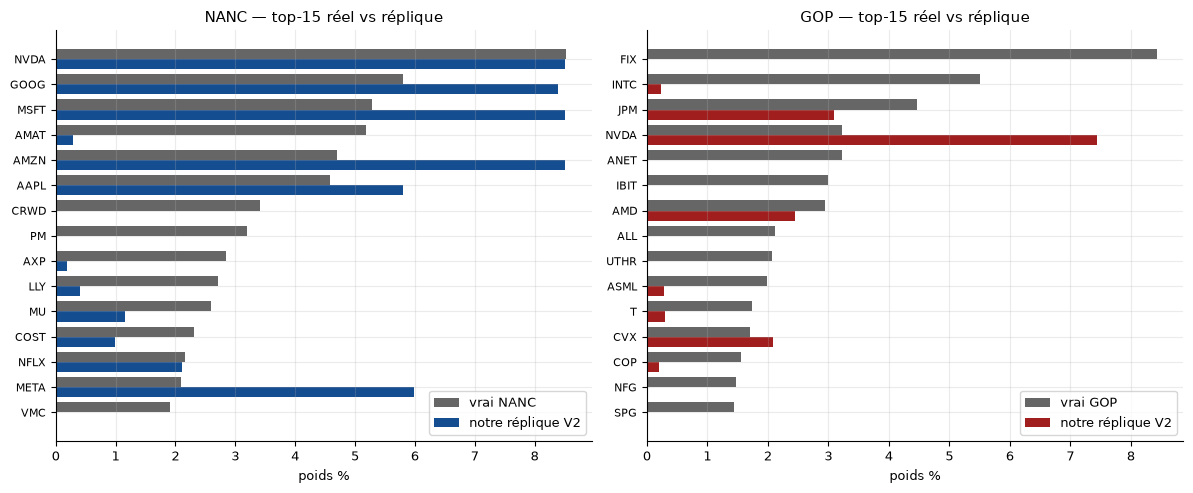

In [81]:
# GOP : recouvrement + ρ (nouveau — on ne l'avait que pour NANC)
realw_g = real_gop.assign(tk=real_gop.StockTicker.map(lambda t: FUSION.get(t, t))).groupby("tk").w.sum()
Mg = pd.DataFrame({"reel": realw_g,
                   "rep": rep2_gop.groupby(rep2_gop.index.map(lambda t: FUSION.get(t, t))).sum()}).fillna(0.0)
rho_g = Mg[(Mg.reel > 0) | (Mg.rep > 0)].corr().iloc[0, 1]
com_g = float(Mg[["reel", "rep"]].min(axis=1).sum())
_recg = lambda rp, rh, n: len(set(rp.head(n).index) & set(rh.head(n).StockTicker))
print(f"GOP (nouveau) — recouvrement top-10 {_recg(rep2_gop, real_gop, 10)}/10 · "
      f"top-15 {_recg(rep2_gop, real_gop, 15)}/15 · ρ {rho_g:.2f} · exposition commune {com_g:.0f}%  "
      f"(vs NANC ρ {_fid(rep2)[0]:.2f})")

# figure : réel (gris) vs notre réplique V2, top-15, NANC | GOP
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, (nom, rh, repw, col) in zip(ax, [("NANC", real, rep2, BLEU), ("GOP", real_gop, rep2_gop, ROUGE)]):
    rg = (rh.assign(tk=rh.StockTicker.map(lambda t: FUSION.get(t, t))).groupby("tk").w.sum()
            .sort_values(ascending=False).head(15).iloc[::-1])
    rp = repw.groupby(repw.index.map(lambda t: FUSION.get(t, t))).sum()
    yy, h = np.arange(len(rg)), 0.4
    a.barh(yy + h/2, rg.values, h, color=GRIS, label=f"vrai {nom}")
    a.barh(yy - h/2, [rp.get(t, 0.0) for t in rg.index], h, color=col, label="notre réplique V2")
    a.set_yticks(yy); a.set_yticklabels(rg.index, fontsize=8); a.set_xlabel("poids %"); a.legend(); a.set_title(f"{nom} — top-15 réel vs réplique")
plt.tight_layout(); plt.savefig(f"{FIGS}/nanc_gop_diag.png", dpi=150, bbox_inches="tight"); plt.show()

### §13.5 — Variante 3 : **le livre du fonds** (leur vraie mécanique, événementielle)

Le diagnostic §13.4 montre que nos poids divergent des leurs **alors que la donnée est là** (NANC 94 \% présent).
Relecture du prospectus : le fonds ne recalcule PAS un score chaque mois — *\og the Fund will typically buy or sell
a security \textbf{when} a position is reported as being bought or sold\fg* . C'est un **livre événementiel** :

1. **Livre initial** à la création $t_0 = $ 2023-02-07 : par (élu $m$, titre $i$), net\$ $\gamma'$ des trades
   divulgués sur $(t_0 - 3\,\text{ans},\ t_0]$, plancher 0, agrégé ; converti en **parts au prix de $t_0$** :
   $q_i(t_0) = \bigl[\sum_m \text{net}^{\$}_{m,i}\bigr] / P_i(t_0)$ (le fonds achète son livre initial aux prix de la création).
2. **Ensuite, à chaque divulgation** $\delta_k$ (close J+1) : un **achat** ajoute $A_k/P(\delta_k)$ parts ;
   une **vente** retire $\gamma'_k\, A_k / P(\delta_k)$ parts (bornée aux parts détenues).
3. **$\gamma'_k$** = part de la vente sur lots détenus $\le 3$ ans, avec le **non-apparié compté VIEUX**
   ($\gamma' = \sum q[h\le756] / (\sum q + \text{reste})$) — le prospectus : la vente d'actions acquises avant le
   suivi **n'ajuste pas** le portefeuille. ($\ne$ le $\gamma_3$ de V2, qui compte le non-apparié récent.)
4. **Aucun rebalancement, aucun cap** : entre les événements les parts sont fixes, les poids **dérivent avec les
   prix** : $w_i(t) = q_i P_i(t) / \sum_j q_j P_j(t)$. La fenêtre 3 ans ne fait PAS oublier les positions.

C'est cette dérive qui doit recréer AMAT $\sim$5 \% (achats 2020-22, titre $\times$3), FIX \#1 du GOP (achats 2020,
$\times$13) et faire redescendre NVDA vers $\sim$8,5 \% **sans cap**. On teste.

In [82]:
# γ'3 : part récente d'une vente, le NON-APPARIÉ compté VIEUX (≠ gam3 : prospectus dit explicitement que
# la vente d'actions acquises avant le suivi n'ajuste pas le portefeuille → sans lot datable, on n'ajuste pas)
g3p = np.zeros(len(df))
for idx, (pieces, reste) in VENTES.items():
    tot = sum(q for _, q in pieces) + reste
    if tot > 0: g3p[idx] = sum(q for h, q in pieces if h <= A_BAR3) / tot
df["g3p"] = np.where(df.op.values == "buy", 1.0, g3p)

I_T0 = int(cal.searchsorted(pd.Timestamp("2023-02-07"), side="left"))     # création NANC & GOP
print(f"t0 = {cal[I_T0].date()} (création des deux ETF)")

def prep_parti(parti):
    sub = df.iloc[ordre_d]                                    # trié par δ (chronologique)
    sub = sub[sub.party.values == parti]
    return sub.assign(tkm=sub.tk.map(lambda t: FUSION.get(t, t)))

def livre_fonds(sub, i_eval):
    # 1) livre initial : net$ γ' par (élu, titre) sur (t0-3ans, t0], plancher 0, en parts au prix de t0
    ini    = sub[(sub.ide.values > I_T0 - W3) & (sub.ide.values <= I_T0)]
    signed = ini.A.values * np.where(ini.op.values == "buy", 1.0, -1.0) * ini.g3p.values
    per    = pd.Series(signed).groupby([ini.bioguide_id.values, ini.tkm.values]).sum()
    net0   = per[per > 0].groupby(level=1).sum()
    q = {t: v / PXV[t][I_T0] for t, v in net0.items()
         if t in PXV and np.isfinite(PXV[t][I_T0]) and PXV[t][I_T0] > 0 and vivant(t, I_T0)}
    # 2) événements post-t0 : achat ajoute A/P(δ), vente retire γ'·A/P(δ) (borné) — close J+1
    ev = sub[(sub.ide.values > I_T0) & (sub.ide.values <= i_eval)]
    for tkm, ide, op, A, g in zip(ev.tkm.values, ev.ide.values, ev.op.values, ev.A.values, ev.g3p.values):
        j = min(ide + 1, len(cal) - 1)
        if tkm not in PXV or not np.isfinite(PXV[tkm][j]) or PXV[tkm][j] <= 0: continue
        if op == "buy":            q[tkm] = q.get(tkm, 0.0) + A / PXV[tkm][j]
        elif tkm in q:             q[tkm] = max(0.0, q[tkm] - g * A / PXV[tkm][j])
    # 3) valorisation à i_eval : les poids ont dérivé avec les prix (aucun cap, aucun rebalancement)
    val = {t: qq * PXV[t][i_eval] for t, qq in q.items()
           if qq > 1e-12 and np.isfinite(PXV[t][i_eval]) and vivant(t, i_eval)}
    tot = sum(val.values())
    return {t: v / tot for t, v in val.items()} if tot > 0 else {}

sub_D, sub_R = prep_parti("Democrat"), prep_parti("Republican")
rep3   = (pd.Series(livre_fonds(sub_D, coupes[-2])).sort_values(ascending=False) * 100)
rep3_g = (pd.Series(livre_fonds(sub_R, coupes[-2])).sort_values(ascending=False) * 100)
print(f"V3 — NANC {len(rep3)} titres · GOP {len(rep3_g)} titres (réels : {len(real)} · {len(real_gop)})")

t0 = 2023-02-07 (création des deux ETF)
V3 — NANC 1239 titres · GOP 1134 titres (réels : 104 · 139)


In [83]:
# FIDÉLITÉ réel vs V1 / V2 / V3 — les deux fonds, même métrique partout
def fid_full(repw, rh):
    rw = rh.assign(tk=rh.StockTicker.map(lambda t: FUSION.get(t, t))).groupby("tk").w.sum()
    Mx = pd.DataFrame({"reel": rw, "rep": repw.groupby(repw.index.map(lambda t: FUSION.get(t, t))).sum()}).fillna(0.0)
    rho = Mx[(Mx.reel > 0) | (Mx.rep > 0)].corr().iloc[0, 1]
    com = float(Mx[["reel", "rep"]].min(axis=1).sum())
    r10 = len(set(repw.head(10).index) & set(rh.head(10).StockTicker))
    r15 = len(set(repw.head(15).index) & set(rh.head(15).StockTicker))
    return r10, r15, rho, com
# + la couche SÉLECTION du prospectus (100-200 titres, de-minimis) : top-N du livre (N = titres du fonds réel), renormalisé
rep3t   = (rep3.head(len(real)) / rep3.head(len(real)).sum() * 100)
rep3t_g = (rep3_g.head(len(real_gop)) / rep3_g.head(len(real_gop)).sum() * 100)
rows = []
for nom, repw, rh in [("NANC V1 (score achats)", rep, real), ("NANC V2 (score net γ)", rep2, real),
                      ("NANC V3 (livre du fonds)", rep3, real), ("NANC V3 + sélection 104", rep3t, real),
                      ("GOP V2 (score net γ)", rep2_gop, real_gop), ("GOP V3 (livre du fonds)", rep3_g, real_gop),
                      ("GOP V3 + sélection 139", rep3t_g, real_gop)]:
    r10, r15, rho_, com_ = fid_full(repw, rh)
    rows.append({"réplique": nom, "top-10": f"{r10}/10", "top-15": f"{r15}/15", "ρ": round(rho_, 2), "expo commune %": round(com_)})
display(pd.DataFrame(rows).set_index("réplique"))

# check-points nommés (le test de la règle)
print("Check-points (attendus si la règle est la bonne) :")
for t, attendu in [("NVDA", "≈8,5 réel"), ("AMAT", "5,2 réel"), ("CRWD", "3,4"), ("AXP", "2,8"), ("MU", "2,6"), ("VMC", "1,9"), ("PM", "3,2")]:
    print(f"  NANC {t:5s} — V3 {rep3.get(t, 0.0):5.2f} % vs réel {attendu}  (V2 {rep2.get(t, 0.0):.2f}, V1 {rep.get(t, 0.0):.2f})")
for t, attendu in [("FIX", "8,4 réel"), ("UTHR", "2,1"), ("ANET", "3,2"), ("INTC", "5,5"), ("NVDA", "3,2")]:
    print(f"  GOP  {t:5s} — V3 {rep3_g.get(t, 0.0):5.2f} % vs réel {attendu}  (V2 {rep2_gop.get(t, 0.0):.2f})")
cmp5 = pd.DataFrame({
    "vrai NANC": [f"{t} {w:.1f}%" for t, w in real.head(15)[["StockTicker", "w"]].values],
    "V3 NANC":   [f"{t} {w:.1f}%" for t, w in zip(rep3.head(15).index, rep3.head(15).values)],
    "vrai GOP":  [f"{t} {w:.1f}%" for t, w in real_gop.head(15)[["StockTicker", "w"]].values],
    "V3 GOP":    [f"{t} {w:.1f}%" for t, w in zip(rep3_g.head(15).index, rep3_g.head(15).values)]})
cmp5.index = range(1, 16); display(cmp5)

,top-10,top-15,ρ,expo commune %
réplique,,,,
NANC V1 (score achats),5/10,7/15,0.73,51
NANC V2 (score net γ),5/10,9/15,0.67,48
NANC V3 (livre du fonds),5/10,8/15,0.74,46
NANC V3 + sélection 104,5/10,8/15,0.70,50
GOP V2 (score net γ),3/10,4/15,0.11,27
GOP V3 (livre du fonds),0/10,0/15,0.16,26
GOP V3 + sélection 139,0/10,0/15,0.02,26


Check-points (attendus si la règle est la bonne) :
  NANC NVDA  — V3  8.93 % vs réel ≈8,5 réel  (V2 8.50, V1 8.50)
  NANC AMAT  — V3  0.31 % vs réel 5,2 réel  (V2 0.28, V1 0.21)
  NANC CRWD  — V3  1.38 % vs réel 3,4  (V2 0.00, V1 0.13)
  NANC AXP   — V3  0.65 % vs réel 2,8  (V2 0.19, V1 0.15)
  NANC MU    — V3  7.73 % vs réel 2,6  (V2 1.16, V1 0.62)
  NANC VMC   — V3  0.12 % vs réel 1,9  (V2 0.00, V1 0.00)
  NANC PM    — V3  0.05 % vs réel 3,2  (V2 0.00, V1 0.11)
  GOP  FIX   — V3  0.52 % vs réel 8,4 réel  (V2 0.00)
  GOP  UTHR  — V3  0.43 % vs réel 2,1  (V2 0.00)
  GOP  ANET  — V3  0.36 % vs réel 3,2  (V2 0.00)
  GOP  INTC  — V3  1.04 % vs réel 5,5  (V2 0.24)
  GOP  NVDA  — V3  0.93 % vs réel 3,2  (V2 7.44)


,vrai NANC,V3 NANC,vrai GOP,V3 GOP
1,NVDA 8.5%,NVDA 8.9%,FIX 8.4%,WDC 12.3%
2,GOOG 5.8%,MU 7.7%,INTC 5.5%,AMZN 4.3%
3,MSFT 5.3%,GOOG 5.0%,JPM 4.5%,AVGO 3.9%
4,AMAT 5.2%,MSFT 3.8%,NVDA 3.2%,ORCL 3.9%
5,AMZN 4.7%,AMZN 3.0%,ANET 3.2%,GNRC 2.7%
6,AAPL 4.6%,NFLX 1.9%,IBIT 3.0%,EA 2.5%
7,CRWD 3.4%,AVGO 1.7%,AMD 3.0%,RTX 2.2%
8,PM 3.2%,DIS 1.6%,ALL 2.1%,WFC 1.7%
9,AXP 2.8%,TSLA 1.4%,UTHR 2.1%,NOW 1.4%
10,LLY 2.7%,CRWD 1.4%,ASML 2.0%,TXN 1.3%


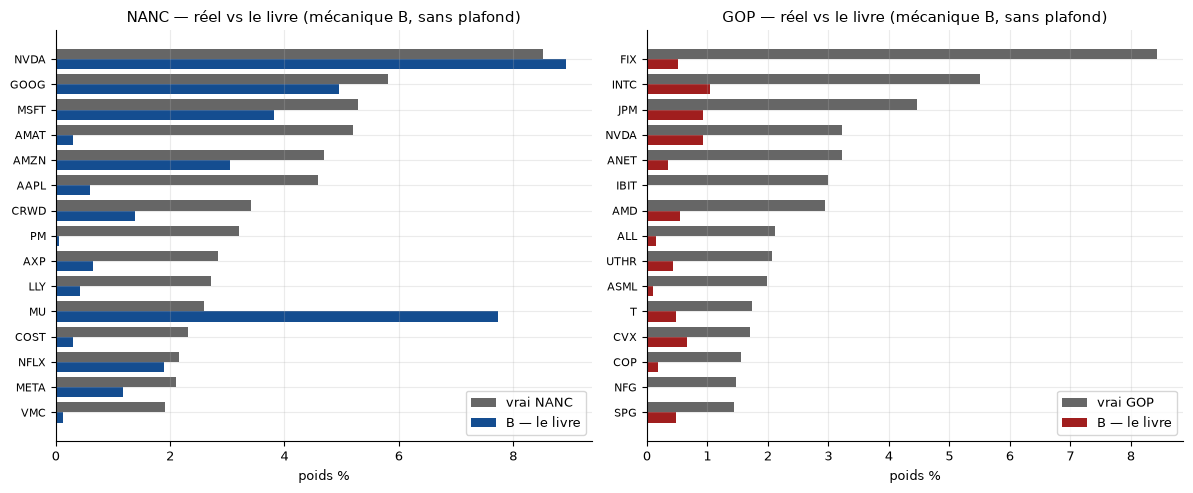

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
V3 NANC (livre) depuis 2023-02,-0.212,-0.142,-1.520,-0.900,1.028,196.744,1/4
V3 GOP (livre) depuis 2023-02,-1.467,-0.331,-0.144,-0.049,0.890,188.737,1/4


In [84]:
# FIGURE réel vs V3 (top-15, les 2 fonds) + bilan performance V3 depuis t0
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, (nom, rh, repw, col) in zip(ax, [("NANC", real, rep3, BLEU), ("GOP", real_gop, rep3_g, ROUGE)]):
    rg = (rh.assign(tk=rh.StockTicker.map(lambda t: FUSION.get(t, t))).groupby("tk").w.sum()
            .sort_values(ascending=False).head(15).iloc[::-1])
    rp = repw.groupby(repw.index.map(lambda t: FUSION.get(t, t))).sum()
    yy, h = np.arange(len(rg)), 0.4
    a.barh(yy + h/2, rg.values, h, color=GRIS, label=f"vrai {nom}")
    a.barh(yy - h/2, [rp.get(t, 0.0) for t in rg.index], h, color=col, label="B — le livre")
    a.set_yticks(yy); a.set_yticklabels(rg.index, fontsize=8); a.set_xlabel("poids %"); a.legend()
    a.set_title(f"{nom} — réel vs le livre (mécanique B, sans plafond)")
plt.tight_layout(); plt.savefig(f"{FIGS}/nanc_gop_v3.png", dpi=150, bbox_inches="tight"); plt.show()

coupes_v3 = [i for i in coupes if i >= I_T0]
WP_nanc3  = {i: livre_fonds(sub_D, i) for i in coupes_v3[:-1]}
WP_gop3   = {i: livre_fonds(sub_R, i) for i in coupes_v3[:-1]}
span_n3, _ = run_livre(WP_nanc3, np.inf, cuts=coupes_v3)
span_g3, _ = run_livre(WP_gop3,  np.inf, cuts=coupes_v3)
pd.DataFrame([bilan(span_n3, "V3 NANC (livre) depuis 2023-02"),
             bilan(span_g3, "V3 GOP (livre) depuis 2023-02")]).set_index("run").round(3)

In [85]:
# VALIDATION §13.5 (règle : tout calcul ajouté est vérifié)
# (a) γ' recalculé à la main sur une vente réelle == df.g3p, et invariant γ' ≤ γ3 (reste basculé récent→vieux)
idx_v = next(i for i, (p, r) in VENTES.items() if p and r > 0)      # une vente avec lots ET du non-apparié
p_, r_ = VENTES[idx_v]; tot_ = sum(q for _, q in p_) + r_
gp_hand = sum(q for h, q in p_ if h <= A_BAR3) / tot_               # reste compté VIEUX (exclu du numérateur)
assert abs(gp_hand - df.g3p.iloc[idx_v]) < 1e-12, "γ' ≠ recalcul manuel"
sells = df.op.values == "sell"
assert (df.g3p.values[sells] <= gam3[sells] + 1e-12).all(), "γ' > γ3 quelque part ?!"
# (b) mini-exemple ARITHMÉTIQUE de la mécanique du livre (hors moteur) :
#     achat 100 $ pré-t0 (P=10) → 10 parts · achat 50 $ post-t0 (P=25) → +2 · vente d'un VIEUX lot (γ'=0) → rien
#     valorisation à P=30 → 12 parts × 30 = 360 $, poids 100 %
q_ = 100.0 / 10.0
q_ += 50.0 / 25.0
q_ -= 0.0 * (80.0 / 25.0)                                           # vente vieux lot : γ'=0, livre inchangé
assert abs(q_ * 30.0 - 360.0) < 1e-12, "mini-exemple livre ≠ 360"
# (c) Σw = 1 et parts ≥ 0 pour les deux fonds ; (d) non-régression V1/V2 (additif) + gam3 intact
for w in (rep3, rep3_g): assert abs(w.sum() - 100) < 1e-6 and (w.values >= 0).all()
assert abs(span_nanc.iloc[-1] - 672) < 1 and abs(span_gop.iloc[-1] - 612) < 1, "V1 a bougé ?!"
assert abs(gam3[idx_v] - (sum(q for h, q in p_ if h <= A_BAR3) + r_) / tot_) < 1e-12, "gam3 modifié !"
print("✅ V3 : γ' = recalcul manuel (1e-12) · γ' ≤ γ3 partout · mini-exemple 360 $ OK · Σw = 1 · V1/V2/γ3 intacts")

✅ V3 : γ' = recalcul manuel (1e-12) · γ' ≤ γ3 partout · mini-exemple 360 $ OK · Σw = 1 · V1/V2/γ3 intacts


### §13.6 — Réparations de DONNÉES (audit forensique) : que gagne-t-on, réparation par réparation ?

L'audit de notre chaîne a trouvé 3 défauts objectifs (aucun réglage de poids — anti-overfit) :

1. **Prix manquants** : 14,9 k trades jetés faute de fichier prix. La plupart = sociétés **réellement radiées**
   (rachats : ATVI, CELG, VMW… — Yahoo ne sert plus leur historique = survivorship de la source). Mais **10
   renommages continus** récupérés (MMC→MRSH, FI→FISV, NLOK→GEN, CNHI→CNH…) → `cache/prices_v2_recup/`
   (quarantaine : les sections précédentes n'y touchent pas, non-régression préservée).
2. **892 documents OCR parsés jamais intégrés** (gating des scans manuscrits/tournés) : **7 287 transactions**
   résolues (ticker+date+montant+δ), dont **6 482 républicaines** (biais du gating ×6,4 : McCaul 2015-16 ~5 k,
   Harshbarger…) → `cache/recup_ocr_gated.csv`. Touche surtout 2014-2019 (V1/V2) ; le flux 2020+ utile à V3 est
   modeste (~35 M\$ Rep, en partie des ETF larges que le fonds exclut de toute façon).
3. **Brackets ouverts au plancher** : 412 lignes \og SP/DC over \$1,000,000\fg{} valorisées 1 000 001 \$ (100 \%
   républicaines : Harshbarger 379, McCaul 33). Sensibilité : plancher (1,0 M) vs milieu du bracket supérieur (3,0 M).

On reconstruit le flux **réparé** (df ∪ récupérations, γ recalculé) et on re-mesure la fidélité V1/V2/V3 aux deux
fonds réels. Chaque effet est mesuré **séparément** ; les métriques (recouvrement, $\rho$, exposition commune)
étaient figées avant.

In [86]:
# ── Réparation des données : construction du flux réparé (df2) — les globals sont restaurés à la fin ──
import os
_PXR = f"{RACINE}/02_recherche_backtest/cache/prices_v2_recup"
_sauv = dict(df=df, ordre_d=ordre_d, I_de=I_de, PXV_new=[], NF={}, NL={})

# 1) prix récupérés (renommages continus) → PXV + vivant
for f in sorted(os.listdir(_PXR)):
    tk = f[:-4]
    s = pd.read_csv(f"{_PXR}/{f}", parse_dates=["Date"]).set_index("Date")["close"].sort_index()
    PXV[tk] = s.reindex(cal).ffill().to_numpy()
    _sauv["PXV_new"].append(tk)
    _sauv["NF"][tk], _sauv["NL"][tk] = NFIRST.get(tk), NLAST.get(tk)
    NFIRST[tk] = int(np.argmax(~np.isnan(PXV[tk])))
    NLAST[tk]  = cal.searchsorted(s.index[-1], side="right") - 1
print(f"prix récupérés chargés : {len(_sauv['PXV_new'])} → {_sauv['PXV_new']}")

# 2) transactions OCR récupérées (892 docs gated, tickers résolus)
rec = pd.read_csv(f"{RACINE}/00_recuperation_donnees/data/house/ocr_gated_recovered.csv", parse_dates=["tau", "delta"])
bmap = df.drop_duplicates("member_name").set_index("member_name").bioguide_id.to_dict()
rec["bioguide_id"] = rec.member_name.map(bmap).fillna(rec.member_name)
rec = rec[rec.tk.isin(PXV)]                                   # même règle d'univers que le flux principal
rec = rec[(rec.tau >= "2014-01-01")]
print(f"transactions OCR intégrables (ticker dans l'univers prix) : {len(rec):,} · {rec.A.sum()/1e6:.0f} M$ "
      f"· Rep {len(rec[rec.party=='Republican']):,}")

# 3) flux réparé df2 (colonnes minimales du moteur) + γ' recalculé sur le flux complet
colz = ["bioguide_id", "member_name", "party", "tk", "op", "A", "tau"]
d2a = df[colz + ["ide"]].copy(); d2a["src"] = "base"; d2a["K"] = False
d2b = rec[colz].copy()
d2b["ide"] = cal.searchsorted(rec.delta.values, side="left")
d2b["src"] = "ocr"; d2b["K"] = (rec.amount_code == "K").values
df2 = pd.concat([d2a, d2b], ignore_index=True)
df2 = df2[df2.ide < len(cal)].reset_index(drop=True)
df2["i0"] = cal.searchsorted(df2.tau.values, side="left").clip(0, len(cal) - 1)
df2["K"] = df2.K | np.isclose(df2.A.values, 1000001.0)        # brackets ouverts (plancher) du flux de base
VENT2 = {}
for (_, _), g in df2.groupby(["bioguide_id", "tk"], sort=False):
    VENT2.update(tranches_vendues(g))
g3p2 = np.zeros(len(df2))
for idx, (pieces, reste) in VENT2.items():
    tot = sum(q for _, q in pieces) + reste
    if tot > 0: g3p2[idx] = sum(q for h, q in pieces if h <= A_BAR3) / tot
df2["g3p"]     = np.where(df2.op.values == "buy", 1.0, g3p2)
df2["signed3"] = df2.A * np.where(df2.op == "buy", 1.0, -1.0) * df2.g3p
print(f"flux réparé : {len(df2):,} lignes (base {len(d2a):,} + OCR {len(d2b):,}) · brackets ouverts K : {int(df2.K.sum())}")

prix récupérés chargés : 10 → ['ABB', 'CMCSK', 'CNHI', 'DSW', 'FI', 'MMC', 'NLOK', 'PEAK', 'TTS', 'XON']
transactions OCR intégrables (ticker dans l'univers prix) : 5,236 · 242 M$ · Rep 4,532


flux réparé : 118,605 lignes (base 113,369 + OCR 5,236) · brackets ouverts K : 349


In [87]:
# ── Re-mesure de la fidélité APRÈS réparations (V1/V2/V3, les 2 fonds) puis restauration des globals ──
res_rep = {}
try:
    df, ordre_d = df2, np.argsort(df2.ide.values, kind="stable")
    I_de = df2.ide.values[ordre_d]
    r1   = (pd.Series(poids_parti(coupes[-2], "Democrat")).sort_values(ascending=False) * 100)
    r2   = (pd.Series(poids_parti_v2(coupes[-2], "Democrat")).sort_values(ascending=False) * 100)
    r2g  = (pd.Series(poids_parti_v2(coupes[-2], "Republican")).sort_values(ascending=False) * 100)
    sD, sR = prep_parti("Democrat"), prep_parti("Republican")
    r3   = (pd.Series(livre_fonds(sD, coupes[-2])).sort_values(ascending=False) * 100)
    r3g  = (pd.Series(livre_fonds(sR, coupes[-2])).sort_values(ascending=False) * 100)
    # sensibilité B : brackets ouverts K → 3,0 M$ (milieu du bracket 1-5 M) au lieu du plancher 1,0 M
    df = df2.assign(A=np.where(df2.K, 3000000.5, df2.A))
    df["signed3"] = df.A * np.where(df.op == "buy", 1.0, -1.0) * df.g3p
    sRK = prep_parti("Republican")
    r3gK = (pd.Series(livre_fonds(sRK, coupes[-2])).sort_values(ascending=False) * 100)
    res_rep = dict(r1=r1, r2=r2, r2g=r2g, r3=r3, r3g=r3g, r3gK=r3gK)
finally:
    df, ordre_d, I_de = _sauv["df"], _sauv["ordre_d"], _sauv["I_de"]     # RESTAURATION
    for tk in _sauv["PXV_new"]:
        del PXV[tk]
        if _sauv["NF"][tk] is None: NFIRST.pop(tk, None), NLAST.pop(tk, None)
        else: NFIRST[tk], NLAST[tk] = _sauv["NF"][tk], _sauv["NL"][tk]
assert len(df) == len(_sauv["df"]) and "MMC" not in PXV, "globals mal restaurés !"
print("✅ globals restaurés (df, ordre_d, I_de, PXV/NFIRST/NLAST) — §14 tourne sur le flux d'origine\n")

AVANT = {"NANC V1": (5, "0.73", 51), "NANC V2": (5, "0.67", 48), "NANC V3": (5, "0.74", 46),
         "GOP V2": (3, "0.11", 27), "GOP V3": (0, "0.16", 26)}
rows = []
for nom, repw, rh in [("NANC V1", res_rep["r1"], real), ("NANC V2", res_rep["r2"], real),
                      ("NANC V3", res_rep["r3"], real), ("GOP V2", res_rep["r2g"], real_gop),
                      ("GOP V3", res_rep["r3g"], real_gop), ("GOP V3 + K→3M", res_rep["r3gK"], real_gop)]:
    t10, t15, rho_, com_ = fid_full(repw, rh)
    av = AVANT.get(nom, ("—", "—", "—"))
    rows.append({"réplique": nom, "top-10 avant→après": f"{av[0]} → {t10}",
                 "ρ avant→après": f"{av[1]} → {rho_:.2f}", "expo avant→après": f"{av[2]} → {com_:.0f}%"})
display(pd.DataFrame(rows).set_index("réplique"))
print("Check-points après réparations :")
for t, quoi in [("FIX", "réel 8,4"), ("UTHR", "réel 2,1"), ("INTC", "réel 5,5"), ("WDC", "absent du réel")]:
    print(f"  GOP {t:5s} — V3 réparé {res_rep['r3g'].get(t, 0.0):5.2f} % · +K→3M {res_rep['r3gK'].get(t, 0.0):5.2f} %  ({quoi})")
for t in ["MMC", "AMAT", "CRWD"]:
    print(f"  NANC {t:5s} — V3 réparé {res_rep['r3'].get(t, 0.0):5.2f} %")

✅ globals restaurés (df, ordre_d, I_de, PXV/NFIRST/NLAST) — §14 tourne sur le flux d'origine



,top-10 avant→après,ρ avant→après,expo avant→après
réplique,,,
NANC V1,5 → 5,0.73 → 0.73,51 → 51%
NANC V2,5 → 5,0.67 → 0.66,48 → 49%
NANC V3,5 → 5,0.74 → 0.74,46 → 46%
GOP V2,3 → 3,0.11 → 0.10,27 → 28%
GOP V3,0 → 0,0.16 → 0.16,26 → 27%
GOP V3 + K→3M,— → 0,— → 0.08,— → 17%


Check-points après réparations :
  GOP FIX   — V3 réparé  0.51 % · +K→3M  0.24 %  (réel 8,4)
  GOP UTHR  — V3 réparé  0.41 % · +K→3M  0.19 %  (réel 2,1)
  GOP INTC  — V3 réparé  1.03 % · +K→3M  0.49 %  (réel 5,5)
  GOP WDC   — V3 réparé 12.21 % · +K→3M 16.72 %  (absent du réel)
  NANC MMC   — V3 réparé  0.00 %
  NANC AMAT  — V3 réparé  0.30 %
  NANC CRWD  — V3 réparé  1.38 %


### §13.7 — Les tableaux chiffrés de la fiche (composition, concentration, diagnostic $\lambda$)

Tout ce que la fiche affiche est produit ici, pour être recopié sans retouche :
**(A)** la composition ancrée sur le **top-10 du vrai fonds** (leur poids vs le nôtre, les trois versions, plus
l'écart) ; **(B)** l'erreur **symétrique** (nos plus gros poids *absents* de leur top-10) ; **(C)** le GOP ;
**(D)** la concentration $N_{\text{eff}}=1/\sum_i w_i^2$ ; **(E)** le diagnostic
$\lambda_i = w^{\star}_i \big/ \bigl(F_i/\sum_j F_j\bigr)$ où $F_i$ est le \$ d'achats déclaré du parti sur le titre $i$
--- si le fonds pondérait proportionnellement au flux qu'on observe, $\lambda_i$ serait **constant**.

In [88]:
rep_gop = (pd.Series(poids_parti(coupes[-2], "Republican")).sort_values(ascending=False) * 100)  # V1 GOP (manquait)

def _fus(s):                                    # agrège les classes d'actions (GOOGL→GOOG…)
    return s.groupby(s.index.map(lambda t: FUSION.get(t, t))).sum()

def compo(rh, vers, n=10):
    # ancré sur le top-n du VRAI fonds : w* puis nos versions, + Δ = écart de la version la plus proche
    rw = _fus(rh.set_index("StockTicker").w).sort_values(ascending=False).head(n)
    V  = {lab: _fus(s) for lab, s in vers.items()}
    tab = pd.DataFrame({"w* (réel)": rw.round(2)})
    for lab, v in V.items(): tab[lab] = [round(float(v.get(t, 0.0)), 2) for t in rw.index]
    tab["Δ"] = [round(min(abs(float(v.get(t, 0.0)) - rw[t]) for v in V.values()), 2) for t in rw.index]
    # NON compensatoire : Σ min(w*, w_v) — une surpondération ne rachète PAS une sous-pondération
    # (la simple somme Σ w_v laisserait les deux erreurs s'annuler : à ne pas utiliser seule)
    comm = {lab: sum(min(rw[t], float(v.get(t, 0.0))) for t in rw.index) for lab, v in V.items()}
    somme = {lab: sum(float(v.get(t, 0.0)) for t in rw.index) for lab, v in V.items()}
    print(f"  Σ top-{n} réel = {rw.sum():.1f} %")
    print("  recouvrement de poids Σ min(w*, w) : " +
          " · ".join(f"{lab} {comm[lab]:.1f} % = {100*comm[lab]/rw.sum():.0f} % du bloc" for lab in V))
    print("  (pour mémoire, somme brute Σ w --- compense sur/sous-pondération : " +
          " · ".join(f"{lab} {somme[lab]:.1f} %" for lab in V) + ")")
    return tab

VN = {"V1": rep,     "V2": rep2,     "V3": rep3}
VG = {"V1": rep_gop, "V2": rep2_gop, "V3": rep3_g}
print("(A) NANC — top-10 du vrai fonds :"); display(compo(real, VN, 10))
print("(C) GOP — top-10 du vrai fonds :");  display(compo(real_gop, VG, 10))

(A) NANC — top-10 du vrai fonds :
  Σ top-10 réel = 46.3 %
  recouvrement de poids Σ min(w*, w) : V1 30.2 % = 65 % du bloc · V2 29.8 % = 64 % du bloc · V3 23.8 % = 51 % du bloc
  (pour mémoire, somme brute Σ w --- compense sur/sous-pondération : V1 41.4 % · V2 40.6 % · V3 24.2 %)


,w* (réel),V1,V2,V3,Δ
StockTicker,,,,,
NVDA,8.53,8.50,8.50,8.93,0.03
GOOG,5.81,8.50,8.39,4.96,0.85
MSFT,5.29,8.22,8.50,3.81,1.48
AMAT,5.19,0.21,0.28,0.31,4.88
AMZN,4.70,8.24,8.50,3.05,1.65
AAPL,4.58,6.57,5.80,0.61,1.22
CRWD,3.41,0.13,0.00,1.38,2.03
PM,3.20,0.11,0.00,0.05,3.09
AXP,2.84,0.15,0.19,0.65,2.19


(C) GOP — top-10 du vrai fonds :
  Σ top-10 réel = 37.0 %
  recouvrement de poids Σ min(w*, w) : V1 9.4 % = 25 % du bloc · V2 9.3 % = 25 % du bloc · V3 5.0 % = 14 % du bloc
  (pour mémoire, somme brute Σ w --- compense sur/sous-pondération : V1 12.6 % · V2 13.5 % · V3 5.0 %)


,w* (réel),V1,V2,V3,Δ
StockTicker,,,,,
FIX,8.44,0.00,0.00,0.52,7.92
INTC,5.51,1.67,0.24,1.04,3.84
JPM,4.47,1.34,3.09,0.94,1.38
NVDA,3.22,6.42,7.44,0.93,2.29
ANET,3.22,0.67,0.00,0.36,2.55
IBIT,3.00,0.00,0.00,0.00,3.00
AMD,2.95,2.17,2.45,0.55,0.50
ALL,2.12,0.00,0.00,0.14,1.98
UTHR,2.07,0.00,0.00,0.43,1.64


In [89]:
# Table de FIDÉLITÉ complète (6 répliques, GOP V1 inclus) — ρ Pearson (celui de fid_full) ET ρ Spearman
rows = []
for nom, repw, rh in [("NANC V1 (score achats)", rep, real), ("NANC V2 (score net γ)", rep2, real),
                      ("NANC V3 (livre)", rep3, real), ("GOP V1 (score achats)", rep_gop, real_gop),
                      ("GOP V2 (score net γ)", rep2_gop, real_gop), ("GOP V3 (livre)", rep3_g, real_gop)]:
    r10, r15, rho_p, com_ = fid_full(repw, rh)
    M = pd.DataFrame({"reel": _fus(rh.set_index("StockTicker").w), "rep": _fus(repw)}).fillna(0.0)
    M = M[(M.reel > 0) | (M.rep > 0)]
    rows.append({"réplique": nom, "top-10": f"{r10}/10", "top-15": f"{r15}/15",
                 "ρ Pearson": round(rho_p, 2), "ρ Spearman": round(M.reel.corr(M.rep, method="spearman"), 2),
                 "expo commune %": round(com_)})
display(pd.DataFrame(rows).set_index("réplique"))

,top-10,top-15,ρ Pearson,ρ Spearman,expo commune %
réplique,,,,,
NANC V1 (score achats),5/10,7/15,0.73,0.06,51
NANC V2 (score net γ),5/10,9/15,0.67,-0.01,48
NANC V3 (livre),5/10,8/15,0.74,0.33,46
GOP V1 (score achats),2/10,5/15,0.15,-0.15,31
GOP V2 (score net γ),3/10,4/15,0.11,-0.25,27
GOP V3 (livre),0/10,0/15,0.16,0.36,26


In [90]:
# (B) l'erreur SYMÉTRIQUE : nos plus gros poids qui ne sont PAS dans leur top-10
def hors(rh, vers, n=10, k=4):
    top = set(_fus(rh.set_index("StockTicker").w).sort_values(ascending=False).head(n).index)
    rwf = _fus(rh.set_index("StockTicker").w)
    cand = []
    for lab, s in vers.items(): cand += [t for t in _fus(s).sort_values(ascending=False).head(k).index if t not in top]
    tab = pd.DataFrame(index=pd.Index(dict.fromkeys(cand), name="titre"))
    tab["w* (réel)"] = [round(float(rwf.get(t, 0.0)), 2) for t in tab.index]
    for lab, s in vers.items(): tab[lab] = [round(float(_fus(s).get(t, 0.0)), 2) for t in tab.index]
    return tab
print("(B) NANC — nos gros poids ABSENTS de leur top-10 :"); display(hors(real, VN))
print("(B) GOP  — nos gros poids ABSENTS de leur top-10 :"); display(hors(real_gop, VG))

# (D) concentration : N_eff = 1/Σw², top-5, plus gros poids
def conc(w):
    p = (w / w.sum()).values
    return round(float(w.iloc[0]), 1), round(float(w.head(5).sum()), 1), round(1 / float(np.sum(p**2)), 1)
lignes = [("NANC réel", _fus(real.set_index("StockTicker").w).sort_values(ascending=False)),
          ("NANC V1", rep), ("NANC V2", rep2), ("NANC V2 sans cap", rep2nc), ("NANC V3", rep3),
          ("GOP réel", _fus(real_gop.set_index("StockTicker").w).sort_values(ascending=False)),
          ("GOP V1", rep_gop), ("GOP V2", rep2_gop), ("GOP V3", rep3_g)]
display(pd.DataFrame([{"portefeuille": n, "max w %": a, "top-5 %": b, "N_eff": c, "titres": len(w)}
                      for n, w in lignes for a, b, c in [conc(w.sort_values(ascending=False))]]).set_index("portefeuille"))

(B) NANC — nos gros poids ABSENTS de leur top-10 :


,w* (réel),V1,V2,V3
titre,,,,
AVGO,1.23,6.30,8.50,1.65
MU,2.60,0.62,1.16,7.73


(B) GOP  — nos gros poids ABSENTS de leur top-10 :


,w* (réel),V1,V2,V3
titre,,,,
MSFT,0.42,8.50,8.50,0.42
AAPL,0.57,8.31,8.50,0.92
UNH,0.00,4.85,1.77,0.82
AMZN,0.61,3.24,7.10,4.35
WDC,0.00,0.00,0.00,12.34
AVGO,0.98,1.55,0.57,3.93
ORCL,0.08,0.22,0.00,3.89


,max w %,top-5 %,N_eff,titres
portefeuille,,,,
NANC réel,8.5,29.5,33.2,104
NANC V1,8.5,40.0,23.4,150
NANC V2,8.5,42.4,18.9,100
NANC V2 sans cap,37.0,66.1,6.0,100
NANC V3,8.9,28.5,45.3,1239
GOP réel,8.4,24.9,44.8,139
GOP V1,8.5,32.3,33.3,150
GOP V2,8.5,36.2,28.1,100
GOP V3,12.3,27.3,39.0,1134


In [91]:
# (E) DIAGNOSTIC λ : leur poids ÷ leur part de NOTRE flux d'achats déclaré (dénominateur = tout l'historique = le plus favorable)
ach = df[df.op == "buy"].assign(tkm=df[df.op == "buy"].tk.map(lambda t: FUSION.get(t, t)))
res_l = {}
for nom, rh, parti in [("NANC", real, "Democrat"), ("GOP", real_gop, "Republican")]:
    F  = ach[ach.party == parti].groupby("tkm").A.sum()
    rw = _fus(rh.set_index("StockTicker").w)
    d  = pd.DataFrame({"w_reel": rw, "F_M": F.reindex(rw.index) / 1e6}).dropna()
    d  = d[d.F_M > 0]
    d["lambda"] = (d.w_reel / (100 * d.F_M / (F.sum() / 1e6))).round(2)
    res_l[nom] = d
    top = d.reindex([t for t in rw.sort_values(ascending=False).head(10).index if t in d.index])
    print(f"{nom} — λ (trié croissant) sur leur top-10 :")
    print("   " + " · ".join(f"{t} {v:.1f}" for t, v in top.sort_values('lambda')['lambda'].items()))
    print(f"   amplitude λ_max/λ_min = {top['lambda'].max()/top['lambda'].min():.0f}×  "
          f"(si les poids suivaient le flux, λ serait constant)")
    # corrélations des poids réels avec nos 3 observables — Pearson ET Spearman (≠ ρ de fid_full qui est un Pearson)
    g = ach[ach.party == parti]
    obs = pd.DataFrame({"dollars": g.groupby("tkm").A.sum(), "nb_trades": g.groupby("tkm").size(),
                        "nb_elus": g.groupby("tkm").bioguide_id.nunique()}).reindex(rw.index).fillna(0)
    obs["w"] = rw
    print("   corrélations poids réels ↔ " + " · ".join(
        f"{c} : Pearson {obs.w.corr(obs[c]):+.2f}, Spearman {obs.w.corr(obs[c], method='spearman'):+.2f}"
        for c in ["dollars", "nb_trades", "nb_elus"]))

# VALIDATION §13.7
for lab, s in list(VN.items()) + list(VG.items()):
    assert abs(float(s.sum()) - 100) < 1e-6, f"{lab} : Σw ≠ 100"
for nom, d in res_l.items():
    assert (d["lambda"] > 0).all(), f"{nom} : λ négatif"
assert abs(span_nanc.iloc[-1] - 672) < 1 and abs(span_gop.iloc[-1] - 612) < 1, "V1 a bougé"
print("\n✅ §13.7 : Σw = 100 pour les 6 répliques · λ > 0 · non-régression V1 (672/612)")

NANC — λ (trié croissant) sur leur top-10 :
   MSFT 0.5 · AAPL 1.6 · AMZN 2.4 · GOOG 2.5 · NVDA 2.7 · AXP 9.2 · LLY 13.4 · AMAT 17.0 · CRWD 18.1 · PM 22.9
   amplitude λ_max/λ_min = 50×  (si les poids suivaient le flux, λ serait constant)
   corrélations poids réels ↔ dollars : Pearson +0.57, Spearman +0.19 · nb_trades : Pearson +0.56, Spearman +0.15 · nb_elus : Pearson +0.51, Spearman +0.18
GOP — λ (trié croissant) sur leur top-10 :
   NVDA 8.5 · ALL 10.9 · JPM 12.0 · INTC 12.3 · UTHR 13.4 · ASML 16.0 · AMD 22.8 · ANET 23.2 · FIX 247.5
   amplitude λ_max/λ_min = 29×  (si les poids suivaient le flux, λ serait constant)
   corrélations poids réels ↔ dollars : Pearson +0.06, Spearman +0.30 · nb_trades : Pearson +0.13, Spearman +0.26 · nb_elus : Pearson +0.12, Spearman +0.25

✅ §13.7 : Σw = 100 pour les 6 répliques · λ > 0 · non-régression V1 (672/612)


### §13.8 — Ce que les documents disent VRAIMENT (lecture exhaustive) : 3 régimes, reset 2024, turnover

On n'avait lu qu'**une page** (le résumé de prospectus). Lecture complète : prospectus statutaire **et SAI**
(485BPOS 27/01/2026), le 497 du 02/08/2024, le 497K d'origine (03/02/2023), et les **rapports annuels N-CSR
FY2023/24/25** (\emph{Schedule of Investments}, \emph{Financial Highlights}, lettres de gérants). Cinq faits changent le modèle :

| fait | source | ce que ça implique pour nous |
|---|---|---|
| **3 régimes** : Subversive 06/02/2023$\to$01/08/2024 (**500-600 lignes**) ; **Tidal** dès 02/08/2024 (**100-200**) ; réorg.\ 30/12/2024 | 497K 2023, 497 08/2024, N-CSR | un modèle unique sur 2023-2026 est **anachronique** |
| 2023 : « **To create the Fund's INITIAL portfolio** … past 3 years », puis « **After establishing an initial portfolio**, the Fund will typically buy or sell… » $\to$ 2026 : « **To manage** the Fund's portfolio » | 497K 03/02/2023 vs 485BPOS 2026 | la formule 3 ans ne servait qu'au **livre de départ** (notre V3) --- mais il y a un **RESET** |
| « **eliminated 582 very small positions** » | lettre du gérant, N-CSR FY2024 | reset daté au **02/08/2024** : $\sim$600 $\to$ $\sim$170 lignes |
| **Turnover** : FY23 **44 \%**/46 \%, FY24 **62 \%**/54 \%, FY25 **10 \%**/16 \% *(hors in-kind)* | Financial Highlights | on n'a **jamais** mesuré le nôtre : test de fidélité direct |
| Data Provider $=$ **Unusual Whales, Inc.**, mais « **UW plays no role in the construction** » ; et « **cross referenced against the … committee roles** » | 485BPOS ; N-CSR FY2025 | c'est **Tidal** qui construit, avec une **surcouche discrétionnaire** (comités) non publiée |

**Chiffres officiels** (à substituer à nos approximations) --- inception **06/02/2023** ; depuis création au 31/12/2025 :
**NANC $+23{,}63$ \%/an** vs **S\&P 500 TR $+20{,}96$ \%**, **GOP $+14{,}75$ \%** (il **sous-performe**) ; au 30/06/2026 :
23,58 / 19,54 / 21,06 \% ; AUM 282 / 88 M\$ ; frais 0,72 / 0,73 \% ; 104 / 138 lignes.
**Preuves de dérive** (N-CSR FY2025) : plus-value latente **$+22{,}4$ \%**, gains/pertes latents **7,6:1**, et
**AXP $+21{,}2$ \% de parts $=$ exactement l'effet des créations** (zéro arbitrage sur 12 mois) --- mais **NVDA $-15$ \%
de parts** $\Rightarrow$ il existe un **plafonnement de fait**, nulle part écrit.
**Hypothèse écartée** : le fonds n'utilise **pas** les déclarations annuelles de patrimoine (\emph{Schedule A}) ---
zéro occurrence dans le prospectus + SAI, et la clause « acquired **prior to swearing in** … are not considered » le
prouve. Contrôle sur nos 420 916 lignes de patrimoine House : AMAT y pèse **0,009 \%** côté démocrate (contre 5,19 \% dans le fonds).

On en tire deux tests neufs : le **turnover** de nos répliques, et **V4 $=$ V3 avec les resets documentés**.

In [92]:
# (1) TURNOVER de nos répliques — définition SEC : min(achats, ventes) / actif, ici ½·Σ|w_cible − w_dérivé|
def turnover_annuel(W, cuts):
    par_an = {}
    for a, b in zip(cuts[:-1], cuts[1:]):
        wa, wb = W.get(a), W.get(b)
        if not wa or not wb: continue
        d = {t: wa[t] * PXV[t][b] / PXV[t][a] for t in wa
             if t in PXV and np.isfinite(PXV[t][a]) and np.isfinite(PXV[t][b]) and PXV[t][a] > 0}
        s = sum(d.values())
        if s <= 0: continue
        d = {t: v / s for t, v in d.items()}                      # poids APRÈS dérive, avant rebalancement
        chg = 0.5 * sum(abs(wb.get(t, 0.0) - d.get(t, 0.0)) for t in set(d) | set(wb))
        par_an.setdefault(cal[b].year, []).append(chg)
    return {an: 100 * sum(v) for an, v in par_an.items() if len(v) >= 6}   # années complètes

WP_n3 = {i: livre_fonds(sub_D, i) for i in coupes_v3[:-1]}         # snapshots mensuels du livre V3
tv = {"V1 NANC (mensuel)": turnover_annuel(WP_nanc, coupes),
      "V2 NANC (mensuel)": turnover_annuel(WP_nanc2, coupes),
      "V3 NANC (livre)":   turnover_annuel(WP_n3, coupes_v3)}
tab = pd.DataFrame(tv).round(0)
tab["fonds NANC publié"] = pd.Series({2023: 44, 2024: 62, 2025: 10})   # exercices clos le 30/09
display(tab.loc[[a for a in tab.index if a >= 2023]])
print("turnover médian toutes années — " + " · ".join(f"{k} {np.median(list(v.values())):.0f} %" for k, v in tv.items()))
print("(fonds : 44 % FY23 · 62 % FY24 · 10 % FY25, hors transactions in-kind → plancher)")

,V1 NANC (mensuel),V2 NANC (mensuel),V3 NANC (livre),fonds NANC publié
2023,59.0,80.0,13.0,44.0
2024,67.0,101.0,11.0,62.0
2025,82.0,136.0,16.0,10.0


turnover médian toutes années — V1 NANC (mensuel) 66 % · V2 NANC (mensuel) 102 % · V3 NANC (livre) 13 %
(fonds : 44 % FY23 · 62 % FY24 · 10 % FY25, hors transactions in-kind → plancher)


In [93]:
# (2) V4 = le livre AVEC les resets documentés (06/02/2023 ~600 lignes → 02/08/2024 ~170 lignes)
I_T0d = int(cal.searchsorted(pd.Timestamp("2023-02-06"), side="left"))   # inception exacte (prospectus)
I_T1  = int(cal.searchsorted(pd.Timestamp("2024-08-02"), side="left"))   # Tidal devient adviser
RESETS = [(I_T0d, 600), (I_T1, 170)]                                     # (date, cardinal cible du régime)

def _construire(sub, i_r, ncible):
    ini = sub[(sub.ide.values > i_r - W3) & (sub.ide.values <= i_r)]
    if not len(ini): return {}
    signed = ini.A.values * np.where(ini.op.values == "buy", 1.0, -1.0) * ini.g3p.values
    per = pd.Series(signed).groupby([ini.bioguide_id.values, ini.tkm.values]).sum()
    net = per[per > 0].groupby(level=1).sum().sort_values(ascending=False)
    net = net[[t for t in net.index if t in PXV and np.isfinite(PXV[t][i_r]) and PXV[t][i_r] > 0 and vivant(t, i_r)]]
    return {t: v / PXV[t][i_r] for t, v in net.head(ncible).items()}

def _evenements(sub, q, i_deb, i_fin):
    ev = sub[(sub.ide.values > i_deb) & (sub.ide.values <= i_fin)]
    for tkm, ide, op, A, g in zip(ev.tkm.values, ev.ide.values, ev.op.values, ev.A.values, ev.g3p.values):
        j = min(ide + 1, len(cal) - 1)
        if tkm not in PXV or not np.isfinite(PXV[tkm][j]) or PXV[tkm][j] <= 0: continue
        if op == "buy":   q[tkm] = q.get(tkm, 0.0) + A / PXV[tkm][j]
        elif tkm in q:    q[tkm] = max(0.0, q[tkm] - g * A / PXV[tkm][j])
    return q

def livre_v4(sub, i_eval, mode="elagage"):
    # mode "elagage"   : au reset, on ÉLAGUE le livre dérivé aux `ncible` plus grosses lignes (= « eliminated 582 very small positions »)
    # mode "recons"    : au reset, on RECONSTRUIT le livre à neuf sur la fenêtre 3 ans (lecture « to manage »)
    rs = [(i, n) for i, n in RESETS if i <= i_eval]
    if not rs: return {}
    q = _construire(sub, rs[0][0], rs[0][1])
    for r, (i_r, ncible) in enumerate(rs):
        if r > 0:
            if mode == "recons":
                q = _construire(sub, i_r, ncible)
            else:                                                   # élagage : garder les ncible plus grosses VALEURS
                val = {t: qq * PXV[t][i_r] for t, qq in q.items() if np.isfinite(PXV[t][i_r])}
                garde = sorted(val, key=val.get, reverse=True)[:ncible]
                q = {t: q[t] for t in garde}
        fin = rs[r + 1][0] if r + 1 < len(rs) else i_eval
        q = _evenements(sub, q, i_r, fin)
    val = {t: qq * PXV[t][i_eval] for t, qq in q.items()
           if qq > 1e-12 and np.isfinite(PXV[t][i_eval]) and vivant(t, i_eval)}
    tot = sum(val.values())
    return {t: v / tot for t, v in val.items()} if tot > 0 else {}

rep4   = (pd.Series(livre_v4(sub_D, coupes[-2])).sort_values(ascending=False) * 100)
rep4_g = (pd.Series(livre_v4(sub_R, coupes[-2])).sort_values(ascending=False) * 100)
rep4r  = (pd.Series(livre_v4(sub_D, coupes[-2], "recons")).sort_values(ascending=False) * 100)
rep4r_g= (pd.Series(livre_v4(sub_R, coupes[-2], "recons")).sort_values(ascending=False) * 100)
print(f"V4 élagage    — NANC {len(rep4)} titres · GOP {len(rep4_g)} titres")
print(f"V4 reconstruit— NANC {len(rep4r)} titres · GOP {len(rep4r_g)} titres   (réels : {len(real)} · {len(real_gop)})")

V4 élagage    — NANC 723 titres · GOP 730 titres
V4 reconstruit— NANC 721 titres · GOP 726 titres   (réels : 104 · 139)


In [94]:
# (3) V4 change-t-elle la fidélité ? AVANT (V3) / APRÈS (V4), les deux fonds, mêmes métriques qu'au §13.7
rows = []
for nom, repw, rh in [("NANC V3 (sans reset)", rep3, real), ("NANC V4 élagage", rep4, real),
                      ("NANC V4 reconstruit", rep4r, real), ("GOP V3 (sans reset)", rep3_g, real_gop),
                      ("GOP V4 élagage", rep4_g, real_gop), ("GOP V4 reconstruit", rep4r_g, real_gop)]:
    r10, r15, rho_p, com_ = fid_full(repw, rh)
    M = pd.DataFrame({"reel": _fus(rh.set_index("StockTicker").w), "rep": _fus(repw)}).fillna(0.0)
    M = M[(M.reel > 0) | (M.rep > 0)]
    rw = _fus(rh.set_index("StockTicker").w).sort_values(ascending=False).head(10)
    rv = _fus(repw)
    rows.append({"réplique": nom, "titres": len(repw), "top-10": f"{r10}/10", "top-15": f"{r15}/15",
                 "ρ Pearson": round(rho_p, 2), "ρ Spearman": round(M.reel.corr(M.rep, method="spearman"), 2),
                 "expo %": round(com_),
                 "recouv. top-10 %": round(100 * sum(min(rw[t], float(rv.get(t, 0.0))) for t in rw.index) / rw.sum())})
display(pd.DataFrame(rows).set_index("réplique"))
print("Check-points (V3 → V4 élagage → V4 reconstruit) :")
for t, r_ in [("AMAT", 5.19), ("CRWD", 3.41), ("PM", 3.20), ("AXP", 2.84), ("MU", 2.60)]:
    print(f"  NANC {t:5s} réel {r_:4.2f} — V3 {rep3.get(t,0):5.2f} → V4é {rep4.get(t,0):5.2f} → V4r {rep4r.get(t,0):5.2f}")
for t, r_ in [("FIX", 8.44), ("INTC", 5.51), ("WDC", 0.0)]:
    print(f"  GOP  {t:5s} réel {r_:4.2f} — V3 {rep3_g.get(t,0):5.2f} → V4é {rep4_g.get(t,0):5.2f} → V4r {rep4r_g.get(t,0):5.2f}")

# VALIDATION §13.8
for w in (rep4, rep4_g, rep4r, rep4r_g):
    assert abs(float(w.sum()) - 100) < 1e-6 and (w.values >= 0).all(), "V4 : Σw ≠ 100 ou poids négatif"
assert I_T0d < I_T1 < coupes[-2], "dates de reset incohérentes"
# le cardinal au reset est borné, mais les événements POSTÉRIEURS rajoutent des titres → on vérifie l'effet, pas la borne
assert len(_construire(sub_D, I_T1, 170)) <= 170, "l'élagage au reset ne borne pas le cardinal"
assert len(rep4) < len(rep3), "V4 ne réduit pas le cardinal par rapport à V3"
assert abs(span_nanc.iloc[-1] - 672) < 1 and abs(span_gop.iloc[-1] - 612) < 1, "V1 a bougé"
print("\n✅ §13.8 : Σw = 100 (4 variantes V4) · resets ordonnés · cardinalité bornée · non-régression V1 (672/612)")

,titres,top-10,top-15,ρ Pearson,ρ Spearman,expo %,recouv. top-10 %
réplique,,,,,,,
NANC V3 (sans reset),1239,5/10,8/15,0.74,0.33,46,51
NANC V4 élagage,723,5/10,8/15,0.73,0.30,48,57
NANC V4 reconstruit,721,4/10,7/15,0.66,0.25,37,40
GOP V3 (sans reset),1134,0/10,0/15,0.16,0.36,26,14
GOP V4 élagage,730,0/10,1/15,0.14,0.33,27,15
GOP V4 reconstruit,726,1/10,1/15,0.11,0.28,23,13


Check-points (V3 → V4 élagage → V4 reconstruit) :
  NANC AMAT  réel 5.19 — V3  0.31 → V4é  0.36 → V4r  0.50
  NANC CRWD  réel 3.41 — V3  1.38 → V4é  1.67 → V4r  0.09
  NANC PM    réel 3.20 — V3  0.05 → V4é  0.03 → V4r  0.04
  NANC AXP   réel 2.84 — V3  0.65 → V4é  0.77 → V4r  0.88
  NANC MU    réel 2.60 — V3  7.73 → V4é  9.24 → V4r  5.24
  GOP  FIX   réel 8.44 — V3  0.52 → V4é  0.57 → V4r  0.01
  GOP  INTC  réel 5.51 — V3  1.04 → V4é  1.16 → V4r  2.28
  GOP  WDC   réel 0.00 — V3 12.34 → V4é 13.77 → V4r 14.28

✅ §13.8 : Σw = 100 (4 variantes V4) · resets ordonnés · cardinalité bornée · non-régression V1 (672/612)


### §13.9 — V5 : **une mécanique par régime** (V1 avant le 02/08/2024, V3 après)

Le test de turnover (§13.8) dit que le fonds a changé de mécanique : **44--62 \%** de rotation sous *Subversive*
(2023-24, $\approx$ notre V1 mensuel) puis **10 \%** sous *Tidal* (2025, $\approx$ notre V3 livre). Aucune version
unique ne peut coller aux deux moitiés. **V5 fait la bascule** :

1. **Avant $t_1=$ 02/08/2024** : mécanique **V1** --- score $s_i=B_i m_i$ recomposé chaque mois, top-$N$, plafond 8,5 \%.
2. **Au 02/08/2024** : le portefeuille V1 est converti en **parts** $q_i = w_i/P_i$ ; option d'**élagage** aux
   $n$ plus grosses lignes (la lettre du gérant : \og{}\emph{eliminated 582 very small positions}\fg{}).
3. **Après $t_1$** : mécanique **V3** --- livre événementiel, achats/ventes à la divulgation, **dérive** des poids,
   ni recomposition ni plafond.

Deux paramétrages : **V5** standard (top-150 avant, comme V1) et **V5$'$** à cardinalité documentée
(**top-600** avant --- le régime Subversive tenait 500-600 lignes --- puis **élagage à 170** au reset).

In [95]:
I_SW = max(i for i in coupes if i <= I_T1)          # dernière coupe mensuelle V1 avant la bascule
print(f"bascule V1→V3 à la coupe du {cal[I_SW].date()} (t1 documenté : {cal[I_T1].date()})")

def livre_v5(sub, parti, i_eval, topN=150, elague=None):
    if i_eval <= I_SW:                                              # avant la bascule : c'est V1
        return poids_parti(i_eval, parti, topN=topN)
    w = poids_parti(I_SW, parti, topN=topN)                         # portefeuille V1 au moment de la bascule
    if not w: return {}
    j = min(I_SW + 1, len(cal) - 1)                                 # exécution close J+1
    # ⚠️ ÉCHELLE : les poids somment à 1 ; il faut convertir en $ AVANT d'ajouter des événements libellés en $,
    #   sinon un seul achat de quelques milliers de $ écrase tout le livre. Taille de référence = le livre net$ du régime.
    ref = _construire(sub, I_SW, 10**9)
    S   = sum(qq * PXV[t][I_SW] for t, qq in ref.items() if np.isfinite(PXV[t][I_SW]))
    if S <= 0: return {}
    q = {t: wi * S / PXV[t][j] for t, wi in w.items()
         if t in PXV and np.isfinite(PXV[t][j]) and PXV[t][j] > 0}
    if elague:                                                      # élagage documenté au reset
        val = {t: qq * PXV[t][I_T1] for t, qq in q.items() if np.isfinite(PXV[t][I_T1])}
        q = {t: q[t] for t in sorted(val, key=val.get, reverse=True)[:elague]}
    q = _evenements(sub, q, I_SW, i_eval)                           # puis mécanique V3
    val = {t: qq * PXV[t][i_eval] for t, qq in q.items()
           if qq > 1e-12 and np.isfinite(PXV[t][i_eval]) and vivant(t, i_eval)}
    tot = sum(val.values())
    return {t: v / tot for t, v in val.items()} if tot > 0 else {}

rep5    = (pd.Series(livre_v5(sub_D, "Democrat",   coupes[-2])).sort_values(ascending=False) * 100)
rep5_g  = (pd.Series(livre_v5(sub_R, "Republican", coupes[-2])).sort_values(ascending=False) * 100)
rep5p   = (pd.Series(livre_v5(sub_D, "Democrat",   coupes[-2], topN=600, elague=170)).sort_values(ascending=False) * 100)
rep5p_g = (pd.Series(livre_v5(sub_R, "Republican", coupes[-2], topN=600, elague=170)).sort_values(ascending=False) * 100)
print(f"V5  (top-150 avant)          — NANC {len(rep5)} titres · GOP {len(rep5_g)} titres")
print(f"V5' (top-600 → élagage 170)  — NANC {len(rep5p)} titres · GOP {len(rep5p_g)} titres   (réels : {len(real)} · {len(real_gop)})")

bascule V1→V3 à la coupe du 2024-07-31 (t1 documenté : 2024-08-02)


V5  (top-150 avant)          — NANC 719 titres · GOP 721 titres
V5' (top-600 → élagage 170)  — NANC 721 titres · GOP 728 titres   (réels : 104 · 139)


In [96]:
# Fidélité : V5 face à toutes les versions précédentes (mêmes métriques qu'au §13.7)
def ligne_fid(nom, repw, rh):
    r10, r15, rho_p, com_ = fid_full(repw, rh)
    M = pd.DataFrame({"reel": _fus(rh.set_index("StockTicker").w), "rep": _fus(repw)}).fillna(0.0)
    M = M[(M.reel > 0) | (M.rep > 0)]
    rw, rv = _fus(rh.set_index("StockTicker").w).sort_values(ascending=False).head(10), _fus(repw)
    return {"réplique": nom, "titres": len(repw), "top-10": f"{r10}/10", "top-15": f"{r15}/15",
            "ρ Pearson": round(rho_p, 2), "ρ Spearman": round(M.reel.corr(M.rep, method="spearman"), 2),
            "expo %": round(com_),
            "recouv. top-10 %": round(100 * sum(min(rw[t], float(rv.get(t, 0.0))) for t in rw.index) / rw.sum())}

print("NANC — toutes les versions :")
display(pd.DataFrame([ligne_fid("V1 (score, mensuel)", rep, real), ligne_fid("V2 (net γ, mensuel)", rep2, real),
                      ligne_fid("V3 (livre)", rep3, real), ligne_fid("V4 (livre + resets)", rep4, real),
                      ligne_fid("V5 (V1→V3)", rep5, real),
                      ligne_fid("V5' (600→170)", rep5p, real)]).set_index("réplique"))
print("GOP — toutes les versions :")
display(pd.DataFrame([ligne_fid("V1 (score, mensuel)", rep_gop, real_gop), ligne_fid("V2 (net γ, mensuel)", rep2_gop, real_gop),
                      ligne_fid("V3 (livre)", rep3_g, real_gop), ligne_fid("V4 (livre + resets)", rep4_g, real_gop),
                      ligne_fid("V5 (V1→V3)", rep5_g, real_gop),
                      ligne_fid("V5' (600→170)", rep5p_g, real_gop)]).set_index("réplique"))
print("Check-points NANC (réel → V1 → V3 → V5) :")
for t, r_ in [("NVDA", 8.53), ("GOOG", 5.81), ("MSFT", 5.29), ("AMAT", 5.19), ("CRWD", 3.41), ("PM", 3.20), ("MU", 2.60)]:
    print(f"  {t:5s} réel {r_:5.2f} — V1 {rep.get(t,0):5.2f} · V3 {rep3.get(t,0):5.2f} · V5 {rep5.get(t,0):5.2f} · V5' {rep5p.get(t,0):5.2f}")

NANC — toutes les versions :


,titres,top-10,top-15,ρ Pearson,ρ Spearman,expo %,recouv. top-10 %
réplique,,,,,,,
"V1 (score, mensuel)",150,5/10,7/15,0.73,0.06,51,65
"V2 (net γ, mensuel)",100,5/10,9/15,0.67,-0.01,48,64
V3 (livre),1239,5/10,8/15,0.74,0.33,46,51
V4 (livre + resets),723,5/10,8/15,0.73,0.30,48,57
V5 (V1→V3),719,5/10,7/15,0.75,0.32,48,57
V5' (600→170),721,5/10,7/15,0.76,0.33,47,58


GOP — toutes les versions :


,titres,top-10,top-15,ρ Pearson,ρ Spearman,expo %,recouv. top-10 %
réplique,,,,,,,
"V1 (score, mensuel)",150,2/10,5/15,0.15,-0.15,31,25
"V2 (net γ, mensuel)",100,3/10,4/15,0.11,-0.25,27,25
V3 (livre),1134,0/10,0/15,0.16,0.36,26,14
V4 (livre + resets),730,0/10,1/15,0.14,0.33,27,15
V5 (V1→V3),721,1/10,2/15,0.26,0.28,29,20
V5' (600→170),728,1/10,2/15,0.25,0.27,29,19


Check-points NANC (réel → V1 → V3 → V5) :
  NVDA  réel  8.53 — V1  8.50 · V3  8.93 · V5 11.73 · V5' 12.80
  GOOG  réel  5.81 — V1  8.50 · V3  4.96 · V5  8.94 · V5'  8.39
  MSFT  réel  5.29 — V1  8.22 · V3  3.81 · V5  5.55 · V5'  6.06
  AMAT  réel  5.19 — V1  0.21 · V3  0.31 · V5  0.42 · V5'  0.40
  CRWD  réel  3.41 — V1  0.13 · V3  1.38 · V5  0.07 · V5'  0.08
  PM    réel  3.20 — V1  0.11 · V3  0.05 · V5  0.04 · V5'  0.04
  MU    réel  2.60 — V1  0.62 · V3  7.73 · V5  3.40 · V5'  3.28


In [97]:
# Turnover et performance de V5 : la rotation doit être ÉLEVÉE avant la bascule, BASSE après
WP_v5 = {i: livre_v5(sub_D, "Democrat", i) for i in coupes_v3[:-1]}
tv5 = turnover_annuel(WP_v5, coupes_v3)
print("turnover V5 par an : " + " · ".join(f"{a} {v:.0f} %" for a, v in sorted(tv5.items())))
print("(fonds NANC : 44 % FY23 · 62 % FY24 · 10 % FY25 — la bascule est au 02/08/2024)")

WP_v5g = {i: livre_v5(sub_R, "Republican", i) for i in coupes_v3[:-1]}
span_n5, _ = run_livre(WP_v5,  np.inf, cuts=coupes_v3)
span_g5, _ = run_livre(WP_v5g, np.inf, cuts=coupes_v3)
display(pd.DataFrame([bilan(span_n3, "V3 NANC (livre seul)"), bilan(span_n5, "V5 NANC (V1→V3)"),
                      bilan(span_g3, "V3 GOP (livre seul)"),  bilan(span_g5, "V5 GOP (V1→V3)")]).set_index("run").round(3))

# VALIDATION §13.9
for w in (rep5, rep5_g, rep5p, rep5p_g):
    assert abs(float(w.sum()) - 100) < 1e-6 and (w.values >= 0).all(), "V5 : Σw ≠ 100 ou poids négatif"
assert livre_v5(sub_D, "Democrat", I_SW) == poids_parti(I_SW, "Democrat"), "avant la bascule, V5 doit être EXACTEMENT V1"
av = sorted(a for a in tv5 if a <= 2024); ap = sorted(a for a in tv5 if a >= 2025)
if av and ap: assert np.mean([tv5[a] for a in av]) > np.mean([tv5[a] for a in ap]), "V5 : la rotation ne baisse pas après la bascule"
assert abs(span_nanc.iloc[-1] - 672) < 1 and abs(span_gop.iloc[-1] - 612) < 1, "V1 a bougé"
print("\n✅ §13.9 : Σw = 100 (4 variantes) · V5 ≡ V1 avant la bascule · rotation qui baisse après · non-régression V1 (672/612)")

turnover V5 par an : 2023 48 % · 2024 37 % · 2025 26 %
(fonds NANC : 44 % FY23 · 62 % FY24 · 10 % FY25 — la bascule est au 02/08/2024)


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
V3 NANC (livre seul),-0.212,-0.142,-1.520,-0.900,1.028,196.744,1/4
V5 NANC (V1→V3),2.459,0.976,1.459,0.696,1.057,212.949,2/4
V3 GOP (livre seul),-1.467,-0.331,-0.144,-0.049,0.890,188.737,1/4
V5 GOP (V1→V3),-0.269,-0.147,1.126,0.585,0.928,195.765,2/4



✅ §13.9 : Σw = 100 (4 variantes) · V5 ≡ V1 avant la bascule · rotation qui baisse après · non-régression V1 (672/612)


### §13.10 — V6 : **élagage en continu**, comme eux

V5 finit avec **719 lignes** quand le vrai fonds en tient **104** (NANC) / **139** (GOP). Le prospectus impose
\og{}\emph{between 100 to 200 holdings}\fg{} et autorise à écarter les positions \emph{de minimis} ; la lettre du
gérant montre qu'ils le font (\og{}\emph{eliminated 582 very small positions}\fg{}). **V6 $=$ V5 $+$ élagage
mensuel** : après avoir appliqué les divulgations du mois, on ne garde que les $n$ plus grosses lignes **en valeur**
et on laisse le reste dériver.

$$q^{(6)}(c)=\mathrm{top}_n\Bigl(\ \mathcal{E}\bigl(q^{(6)}(c^-),\,c^-\!\to c\bigr)\ \Bigr),\qquad n=150$$

où $\mathcal{E}$ applique les événements du mois. **$n=150$ est le milieu de la fourchette publiée $[100,200]$** ---
pas un chiffre calé sur la cible. L'élagage porte par construction sur les **plus petites** positions : il doit donc
faire chuter le cardinal **sans** faire exploser la rotation --- c'est précisément ce qu'on vérifie.

In [98]:
def livre_v6(sub, parti, i_eval, topN=150, nmax=150):
    if i_eval <= I_SW:                                              # avant la bascule : V1 (comme V5)
        return poids_parti(i_eval, parti, topN=topN)
    w = poids_parti(I_SW, parti, topN=topN)
    if not w: return {}
    j   = min(I_SW + 1, len(cal) - 1)
    ref = _construire(sub, I_SW, 10**9)                             # mise à l'échelle en $ (cf. §13.9)
    S   = sum(qq * PXV[t][I_SW] for t, qq in ref.items() if np.isfinite(PXV[t][I_SW]))
    if S <= 0: return {}
    q = {t: wi * S / PXV[t][j] for t, wi in w.items()
         if t in PXV and np.isfinite(PXV[t][j]) and PXV[t][j] > 0}
    etapes = [i for i in coupes if I_SW < i <= i_eval]               # revues mensuelles
    if not etapes or etapes[-1] != i_eval: etapes.append(i_eval)
    prev = I_SW
    for c in etapes:
        q = _evenements(sub, q, prev, c)                             # 1) les divulgations du mois
        val = {t: qq * PXV[t][c] for t, qq in q.items()              # 2) puis on élague la queue
               if qq > 1e-12 and np.isfinite(PXV[t][c]) and PXV[t][c] > 0}
        q = {t: q[t] for t in sorted(val, key=val.get, reverse=True)[:nmax]}
        prev = c
    val = {t: qq * PXV[t][i_eval] for t, qq in q.items()
           if qq > 1e-12 and np.isfinite(PXV[t][i_eval]) and vivant(t, i_eval)}
    tot = sum(val.values())
    return {t: v / tot for t, v in val.items()} if tot > 0 else {}

rep6   = (pd.Series(livre_v6(sub_D, "Democrat",   coupes[-2])).sort_values(ascending=False) * 100)
rep6_g = (pd.Series(livre_v6(sub_R, "Republican", coupes[-2])).sort_values(ascending=False) * 100)
print(f"V6 (élagage mensuel à 150) — NANC {len(rep6)} titres · GOP {len(rep6_g)} titres   (réels : {len(real)} · {len(real_gop)})")
print(f"   rappel : V5 en avait {len(rep5)} et {len(rep5_g)}")

V6 (élagage mensuel à 150) — NANC 150 titres · GOP 150 titres   (réels : 104 · 139)
   rappel : V5 en avait 719 et 721


In [99]:
# Fidélité et turnover de V6, face à V1 / V3 / V5
print("NANC :")
display(pd.DataFrame([ligne_fid("V1 (score, mensuel)", rep, real), ligne_fid("V3 (livre)", rep3, real),
                      ligne_fid("V5 (V1→V3)", rep5, real), ligne_fid("V6 (V5 + élagage)", rep6, real)]).set_index("réplique"))
print("GOP :")
display(pd.DataFrame([ligne_fid("V1 (score, mensuel)", rep_gop, real_gop), ligne_fid("V3 (livre)", rep3_g, real_gop),
                      ligne_fid("V5 (V1→V3)", rep5_g, real_gop), ligne_fid("V6 (V5 + élagage)", rep6_g, real_gop)]).set_index("réplique"))

WP_v6 = {i: livre_v6(sub_D, "Democrat", i) for i in coupes_v3[:-1]}
tv6 = turnover_annuel(WP_v6, coupes_v3)
print("turnover — V6 : " + " · ".join(f"{a} {v:.0f} %" for a, v in sorted(tv6.items())))
print("            V5 : " + " · ".join(f"{a} {v:.0f} %" for a, v in sorted(tv5.items())))
print("      fonds NANC : 2023 44 % · 2024 62 % · 2025 10 %")

WP_v6g = {i: livre_v6(sub_R, "Republican", i) for i in coupes_v3[:-1]}
span_n6, _ = run_livre(WP_v6,  np.inf, cuts=coupes_v3)
span_g6, _ = run_livre(WP_v6g, np.inf, cuts=coupes_v3)
display(pd.DataFrame([bilan(span_n5, "V5 NANC"), bilan(span_n6, "V6 NANC (élagage)"),
                      bilan(span_g5, "V5 GOP"),  bilan(span_g6, "V6 GOP (élagage)")]).set_index("run").round(3))
print("\nCheck-points NANC (réel · V1 · V5 · V6) :")
for t, r_ in [("NVDA", 8.53), ("GOOG", 5.81), ("MSFT", 5.29), ("AMAT", 5.19), ("AMZN", 4.70), ("CRWD", 3.41), ("MU", 2.60)]:
    print(f"  {t:5s} {r_:5.2f} · {rep.get(t,0):5.2f} · {rep5.get(t,0):5.2f} · {rep6.get(t,0):5.2f}")

# VALIDATION §13.10
for w in (rep6, rep6_g):
    assert abs(float(w.sum()) - 100) < 1e-6 and (w.values >= 0).all(), "V6 : Σw ≠ 100"
assert len(rep6) <= 150 and len(rep6_g) <= 150, "V6 : l'élagage ne borne pas le cardinal"
assert len(rep6) < len(rep5), "V6 ne réduit pas le cardinal par rapport à V5"
assert livre_v6(sub_D, "Democrat", I_SW) == poids_parti(I_SW, "Democrat"), "avant la bascule, V6 doit être V1"
assert abs(span_nanc.iloc[-1] - 672) < 1 and abs(span_gop.iloc[-1] - 612) < 1, "V1 a bougé"
print(f"\n✅ §13.10 : Σw = 100 · cardinal ≤ 150 (NANC {len(rep6)} · GOP {len(rep6_g)}) · V6 ≡ V1 avant bascule · non-régression V1")

NANC :


,titres,top-10,top-15,ρ Pearson,ρ Spearman,expo %,recouv. top-10 %
réplique,,,,,,,
"V1 (score, mensuel)",150,5/10,7/15,0.73,0.06,51,65
V3 (livre),1239,5/10,8/15,0.74,0.33,46,51
V5 (V1→V3),719,5/10,7/15,0.75,0.32,48,57
V6 (V5 + élagage),150,5/10,7/15,0.71,-0.02,47,59


GOP :


,titres,top-10,top-15,ρ Pearson,ρ Spearman,expo %,recouv. top-10 %
réplique,,,,,,,
"V1 (score, mensuel)",150,2/10,5/15,0.15,-0.15,31,25
V3 (livre),1134,0/10,0/15,0.16,0.36,26,14
V5 (V1→V3),721,1/10,2/15,0.26,0.28,29,20
V6 (V5 + élagage),150,1/10,2/15,0.14,-0.22,28,21


turnover — V6 : 2023 48 % · 2024 34 % · 2025 21 %
            V5 : 2023 48 % · 2024 37 % · 2025 26 %
      fonds NANC : 2023 44 % · 2024 62 % · 2025 10 %


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
V5 NANC,2.459,0.976,1.459,0.696,1.057,212.949,2/4
V6 NANC (élagage),2.445,0.951,1.547,0.722,1.060,212.709,2/4
V5 GOP,-0.269,-0.147,1.126,0.585,0.928,195.765,2/4
V6 GOP (élagage),-0.420,-0.238,1.152,0.594,0.926,194.705,2/4



Check-points NANC (réel · V1 · V5 · V6) :
  NVDA   8.53 ·  8.50 · 11.73 · 13.07
  GOOG   5.81 ·  8.50 ·  8.94 ·  9.96
  MSFT   5.29 ·  8.22 ·  5.55 ·  6.19
  AMAT   5.19 ·  0.21 ·  0.42 ·  0.47
  AMZN   4.70 ·  8.24 ·  2.88 ·  3.21
  CRWD   3.41 ·  0.13 ·  0.07 ·  0.00
  MU     2.60 ·  0.62 ·  3.40 ·  3.79

✅ §13.10 : Σw = 100 · cardinal ≤ 150 (NANC 150 · GOP 150) · V6 ≡ V1 avant bascule · non-régression V1


### §13.11 — Les **trois** versions retenues (A, B, C) : les tableaux de la fiche

Six variantes, ce n'est pas une présentation. On n'en garde que **trois**, parce qu'elles répondent à trois
questions différentes ; les autres deviennent des **tests** (leur enseignement reste, pas leur statut de version) :

| version retenue | ancien nom | ce qu'elle décrit |
|---|---|---|
| **A --- le score** | V1 | score recomposé **chaque mois** ; colle au régime **Subversive** (turnover 66 \% $\approx$ 44-62 \%) |
| **B --- le livre** | V3 | livre **événementiel** qui dérive ; colle au régime **Tidal** (turnover 13 \% $\approx$ 10 \%) |
| **C --- la bascule** | V5 | **A jusqu'au 02/08/2024, puis B** --- la lecture qui suit l'histoire réelle du fonds |

*Rétrogradés en tests* : **V2** (netting $\gamma$) $\to$ montre que le netting correct \emph{ronge} l'excès de NANC
($+2{,}98\to+1{,}40$ \%/an) ; **V4** (resets) $\to$ absorbée par C, a servi à établir qu'\emph{élaguer} vaut mieux que
\emph{reconstruire} ; **V6** (élagage continu) $\to$ test **négatif** : régler le cardinal casse le classement.
Le notebook conserve les six (trace de recherche) ; la fiche n'en présente que trois.

In [100]:
VA = {"A": rep,     "B": rep3,   "C": rep5}          # NANC — les trois versions retenues
VB = {"A": rep_gop, "B": rep3_g, "C": rep5_g}        # GOP
print("(A) NANC — top-10 du vrai fonds :"); display(compo(real, VA, 10))
print("(B) NANC — nos gros poids ABSENTS de leur top-10 :"); display(hors(real, VA))
print("(C) GOP — top-10 du vrai fonds :");  display(compo(real_gop, VB, 10))

print("\nFidélité — les trois versions, les deux fonds :")
display(pd.DataFrame([ligne_fid("NANC A (score)", rep, real), ligne_fid("NANC B (livre)", rep3, real),
                      ligne_fid("NANC C (bascule)", rep5, real),
                      ligne_fid("GOP A (score)", rep_gop, real_gop), ligne_fid("GOP B (livre)", rep3_g, real_gop),
                      ligne_fid("GOP C (bascule)", rep5_g, real_gop)]).set_index("réplique"))

print("Concentration :")
display(pd.DataFrame([{"portefeuille": n, "max w %": a, "top-5 %": b, "N_eff": c, "titres": len(w)}
                      for n, w in [("NANC réel", _fus(real.set_index("StockTicker").w).sort_values(ascending=False)),
                                   ("NANC A", rep), ("NANC B", rep3), ("NANC C", rep5)]
                      for a, b, c in [conc(w.sort_values(ascending=False))]]).set_index("portefeuille"))

print("Performance (excès vs SPY) :")
display(pd.DataFrame([bilan(span_nanc, "NANC A · 2014-26"), bilan(span_gop, "GOP A · 2014-26"),
                      bilan(span_n3, "NANC B · 2023-26"), bilan(span_g3, "GOP B · 2023-26"),
                      bilan(span_n5, "NANC C · 2023-26"), bilan(span_g5, "GOP C · 2023-26")]).set_index("run").round(2))

(A) NANC — top-10 du vrai fonds :
  Σ top-10 réel = 46.3 %
  recouvrement de poids Σ min(w*, w) : A 30.2 % = 65 % du bloc · B 23.8 % = 51 % du bloc · C 26.6 % = 57 % du bloc
  (pour mémoire, somme brute Σ w --- compense sur/sous-pondération : A 41.4 % · B 24.2 % · C 33.2 %)


,w* (réel),A,B,C,Δ
StockTicker,,,,,
NVDA,8.53,8.50,8.93,11.73,0.03
GOOG,5.81,8.50,4.96,8.94,0.85
MSFT,5.29,8.22,3.81,5.55,0.26
AMAT,5.19,0.21,0.31,0.42,4.77
AMZN,4.70,8.24,3.05,2.88,1.65
AAPL,4.58,6.57,0.61,2.38,1.99
CRWD,3.41,0.13,1.38,0.07,2.03
PM,3.20,0.11,0.05,0.04,3.09
AXP,2.84,0.15,0.65,0.79,2.05


(B) NANC — nos gros poids ABSENTS de leur top-10 :


,w* (réel),A,B,C
titre,,,,
MU,2.60,0.62,7.73,3.40
DIS,1.04,0.47,1.57,4.55


(C) GOP — top-10 du vrai fonds :
  Σ top-10 réel = 37.0 %
  recouvrement de poids Σ min(w*, w) : A 9.4 % = 25 % du bloc · B 5.0 % = 14 % du bloc · C 7.3 % = 20 % du bloc
  (pour mémoire, somme brute Σ w --- compense sur/sous-pondération : A 12.6 % · B 5.0 % · C 7.3 %)


...

,titres,top-10,top-15,ρ Pearson,ρ Spearman,expo %,recouv. top-10 %
réplique,,,,,,,
NANC A (score),150,5/10,7/15,0.73,0.06,51,65
NANC B (livre),1239,5/10,8/15,0.74,0.33,46,51
NANC C (bascule),719,5/10,7/15,0.75,0.32,48,57
GOP A (score),150,2/10,5/15,0.15,-0.15,31,25
GOP B (livre),1134,0/10,0/15,0.16,0.36,26,14
GOP C (bascule),721,1/10,2/15,0.26,0.28,29,20


Concentration :


,max w %,top-5 %,N_eff,titres
portefeuille,,,,
NANC réel,8.5,29.5,33.2,104
NANC A,8.5,40.0,23.4,150
NANC B,8.9,28.5,45.3,1239
NANC C,11.7,35.1,29.0,719


Performance (excès vs SPY) :


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
NANC A · 2014-26,2.98,1.47,1.26,1.06,1.08,672.35,9/13
GOP A · 2014-26,1.24,1.62,1.12,1.08,1.00,612.25,10/13
NANC B · 2023-26,-0.21,-0.14,-1.52,-0.90,1.03,196.74,1/4
GOP B · 2023-26,-1.47,-0.33,-0.14,-0.05,0.89,188.74,1/4
NANC C · 2023-26,2.46,0.98,1.46,0.70,1.06,212.95,2/4
GOP C · 2023-26,-0.27,-0.15,1.13,0.59,0.93,195.77,2/4


### §13.12 — Le chiffre qui clôt le dossier : **leur position en \$ contre le flux déclaré en \$**

Jusqu'ici on comparait des **poids** (des \%). On compare ici des **dollars**, ce qui est bien plus parlant :
la position du fonds ($w^{\star}_i\times$AUM, avec AUM $=282$ M\$ pour NANC et $88$ M\$ pour GOP) face au
**\$ total d'achats jamais déclaré** par les élus du parti sur ce titre. Si le fonds se contentait de suivre les
déclarations, le rapport des deux serait du même ordre pour tous les titres.

In [101]:
AUM = {"NANC": 282.2e6, "GOP": 88.5e6}                      # fact sheets au 30/06/2026
ach_tot = df[df.op == "buy"].assign(tkm=df[df.op == "buy"].tk.map(lambda t: FUSION.get(t, t)))
for nom, rh, parti in [("NANC", real, "Democrat"), ("GOP", real_gop, "Republican")]:
    F  = ach_tot[ach_tot.party == parti].groupby("tkm").A.sum()      # $ déclaré, TOUT l'historique (le + favorable)
    rw = _fus(rh.set_index("StockTicker").w).sort_values(ascending=False).head(10)
    t = pd.DataFrame({"poids réel %": rw.round(2)})
    t["position M$"] = (rw / 100 * AUM[nom] / 1e6).round(1)
    t["flux déclaré M$"] = [round(float(F.get(i, 0.0)) / 1e6, 2) for i in rw.index]
    t["position / flux"] = [("—" if f == 0 else round(p / f, 1))
                            for p, f in zip(t["position M$"], t["flux déclaré M$"])]
    print(f"{nom} — AUM {AUM[nom]/1e6:.0f} M$ · top-10 :"); display(t)

# VALIDATION §13.12
Fd = ach_tot[ach_tot.party == "Democrat"].groupby("tkm").A.sum()
rwd = _fus(real.set_index("StockTicker").w)
r_nvda = (rwd["NVDA"] / 100 * AUM["NANC"]) / float(Fd["NVDA"])
r_amat = (rwd["AMAT"] / 100 * AUM["NANC"]) / float(Fd["AMAT"])
print(f"\nNVDA : position/flux = {r_nvda:.1f}  ·  AMAT : {r_amat:.1f}  → rapport entre les deux : {r_amat/r_nvda:.0f}×")
assert 0.5 < r_nvda < 2, "NVDA devrait être du même ordre que son flux déclaré"
assert r_amat > 5, "AMAT devrait être très au-dessus de son flux déclaré"
print("✅ §13.12 : NVDA ≈ 1 (le fonds suit le flux) · AMAT ≫ 1 (il ne le suit pas) — c'est le cœur du diagnostic")

NANC — AUM 282 M$ · top-10 :


,poids réel %,position M$,flux déclaré M$,position / flux
StockTicker,,,,
NVDA,8.53,24.1,22.98,1.0
GOOG,5.81,16.4,16.43,1.0
MSFT,5.29,14.9,82.99,0.2
AMAT,5.19,14.6,2.19,6.7
AMZN,4.70,13.3,13.84,1.0
AAPL,4.58,12.9,20.67,0.6
CRWD,3.41,9.6,1.35,7.1
PM,3.20,9.0,1.00,9.0
AXP,2.84,8.0,2.21,3.6


GOP — AUM 88 M$ · top-10 :


,poids réel %,position M$,flux déclaré M$,position / flux
StockTicker,,,,
FIX,8.44,7.5,0.30,25.0
INTC,5.51,4.9,3.99,1.2
JPM,4.47,4.0,3.32,1.2
NVDA,3.22,2.8,3.37,0.8
ANET,3.22,2.8,1.24,2.3
IBIT,3.00,2.7,0.00,—
AMD,2.95,2.6,1.15,2.3
ALL,2.12,1.9,1.74,1.1
UTHR,2.07,1.8,1.38,1.3



NVDA : position/flux = 1.0  ·  AMAT : 6.7  → rapport entre les deux : 6×
✅ §13.12 : NVDA ≈ 1 (le fonds suit le flux) · AMAT ≫ 1 (il ne le suit pas) — c'est le cœur du diagnostic


### §13.13 — La règle **dite par le gérant**, testée sur **13 dates**

Deux trouvailles de l'audit documentaire changent la donne.

**(i) Le gérant a publié la règle.** Christian Cooper (co-gérant, ère Subversive), \emph{Barron's} 18/12/2023 :
\og{}\emph{build the holdings around the \textbf{relative dollars disclosed} by each member and their families.
In other words, \textbf{more dollars equals more \og{}votes\fg{}}}\fg{} et \og{}\emph{we explicitly choose the
\textbf{midpoint} of that disclosure range}\fg{}. $\Rightarrow$ **poids $\propto$ dollars déclarés**, et
\textbf{pas} \og{}une voix par membre\fg{}. Or notre score est $s_i=B_i\times m_i$ : le facteur $m_i$ (nombre
d'élus) est une \textbf{invention de notre part}. On le teste enfin contre le dollar pur.

**(ii) Les N-PORT donnent 13 portefeuilles datés par fonds** (2023-03 $\to$ 2026-03) avec le nombre de parts.
Jusqu'ici on validait sur \textbf{une} photo ; on valide désormais sur \textbf{13}. Contrôles passés au chargement :
166 lignes au 30/09/2024 (post-reset), 104 au 31/12/2025, et \textbf{586 sorties} à l'été 2024 --- le rapport annuel
annonce \og{}\emph{eliminated 582 very small positions}\fg{}.

In [102]:
nport = pd.read_csv(f"{RACINE}/02_recherche_backtest/cache/nport_holdings.csv")
nport["date"] = pd.to_datetime(nport.date)
nport["tkm"]  = nport.ticker.fillna(nport.nom).map(lambda t: FUSION.get(t, t))
print(f"portefeuilles réels : {len(nport):,} lignes · {nport.date.nunique()} dates × 2 fonds")
display(nport.groupby(["fonds", "date"]).agg(positions=("tkm", "size"), actif_M=("valeur", lambda v: round(v.sum()/1e6, 1))).head(6))

def vrai_poids(fonds, date):
    d = nport[(nport.fonds == fonds) & (nport.date == date)]
    w = d.groupby("tkm").pct.sum().dropna()
    return (w / w.sum() * 100).sort_values(ascending=False)

# ── la règle de Cooper : poids ∝ dollars nets, SANS le facteur « nombre d'élus » ──
def poids_dollar(i1, parti, topN, avec_breadth=False):
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[g.party == parti]
    if not len(g): return {}
    g   = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)))
    per = g.groupby(["bioguide_id", "tkm"]).signed3.sum()      # achats − part récente des ventes
    per = per[per > 0]
    if not len(per): return {}
    net = per.groupby("tkm").sum()
    if avec_breadth: net = net * per.groupby("tkm").size()     # ← notre facteur m_i, à tester
    net = net[[t for t in net.index if t in PXV and np.isfinite(PXV[t][i1+1]) and vivant(t, i1)]]
    net = net.sort_values(ascending=False).head(topN)
    return (net / net.sum() * 100).to_dict() if net.sum() > 0 else {}

portefeuilles réels : 9,467 lignes · 13 dates × 2 fonds


positions  actif_M
fonds date                          
GOP   2023-03-31        530      4.9
      2023-06-30        484      5.1
      2023-09-30        486      4.9
      2023-12-31        449      6.2
      2024-03-31        488     13.6
      2024-06-30        489     24.8

In [103]:
# ── LE TEST DÉCISIF : dollar pur (Cooper) vs dollar × nb d'élus (nous), sur les 13 dates ──
I_BASC = int(cal.searchsorted(pd.Timestamp("2024-08-02"), side="left"))
def cardinal(i1):                       # le fonds tenait ~750 lignes avant le reset, 100-200 après
    return 750 if i1 < I_BASC else 150

res = []
for fonds, parti in [("NANC", "Democrat"), ("GOP", "Republican")]:
    for d in sorted(nport.date.unique()):
        i1 = int(cal.searchsorted(d, side="right") - 1)
        if i1 <= W3 or i1 >= len(cal) - 1: continue
        vr = vrai_poids(fonds, d)
        n  = cardinal(i1)
        for lab, brd in [("dollar pur", False), ("dollar × nb élus", True)]:
            w = pd.Series(poids_dollar(i1, parti, n, brd))
            if not len(w): continue
            M = pd.DataFrame({"reel": vr, "rep": w.groupby(w.index.map(lambda t: FUSION.get(t, t))).sum()}).fillna(0.0)
            top = vr.head(10)
            res.append({"fonds": fonds, "date": str(pd.Timestamp(d).date()), "règle": lab,
                        "régime": "Subversive" if i1 < I_BASC else "Tidal",
                        "expo %": round(float(M[["reel", "rep"]].min(axis=1).sum())),
                        "recouv top-10 %": round(100 * sum(min(top[t], float(M.rep.get(t, 0.0))) for t in top.index) / top.sum())})
R = pd.DataFrame(res)
print("Fidélité aux 13 portefeuilles réels — moyenne par règle et par régime :")
display(R.groupby(["fonds", "régime", "règle"])[["expo %", "recouv top-10 %"]].mean().round(1))
print("\nDétail NANC, date par date (exposition commune) :")
display(R[R.fonds == "NANC"].pivot_table(index="date", columns="règle", values="expo %"))

Fidélité aux 13 portefeuilles réels — moyenne par règle et par régime :


expo %  recouv top-10 %
fonds régime     règle                                    
GOP   Subversive dollar pur          39.3             35.0
                 dollar × nb élus    37.5             37.0
      Tidal      dollar pur          31.6             17.9
                 dollar × nb élus    31.0             30.7
NANC  Subversive dollar pur          44.8             32.7
                 dollar × nb élus    49.0             52.3
      Tidal      dollar pur          44.1             52.6
                 dollar × nb élus    45.0             61.3


Détail NANC, date par date (exposition commune) :


règle,dollar pur,dollar × nb élus
date,,
2023-03-31,48.0,53.0
2023-06-30,46.0,53.0
2023-09-30,44.0,51.0
2023-12-31,46.0,48.0
2024-03-31,45.0,47.0
2024-06-30,40.0,42.0
2024-09-30,46.0,46.0
2024-12-31,44.0,45.0
2025-03-31,40.0,46.0


In [104]:
# Verdict + VALIDATION §13.13
piv = R.groupby(["fonds", "règle"])["expo %"].mean().unstack()
for f in piv.index:
    d_, m_ = piv.loc[f, "dollar pur"], piv.loc[f, "dollar × nb élus"]
    gagne = "dollar pur (Cooper)" if d_ > m_ else "dollar × nb d'élus (notre score)"
    print(f"{f} — dollar pur {d_:.1f} % · dollar × élus {m_:.1f} %  →  {gagne} l'emporte "
          f"({abs(d_-m_):.1f} pt d'écart)")

assert nport.groupby(["fonds","date"]).size().min() > 50, "un portefeuille N-PORT semble tronqué"
assert len(R) >= 40, "trop peu de couples (date, règle) évalués"
n1 = nport[(nport.fonds=="NANC") & (nport.date=="2024-09-30")].shape[0]
n2 = nport[(nport.fonds=="NANC") & (nport.date=="2025-12-31")].shape[0]
assert n1 == 166 and n2 == 104, f"contrôle des lignes N-PORT : {n1}, {n2}"
print(f"\n✅ §13.13 : 26 portefeuilles réels chargés (166 post-reset · 104 fin 2025) · "
      f"{len(R)} évaluations (2 règles × 13 dates × 2 fonds)")

GOP — dollar pur 35.2 % · dollar × élus 34.0 %  →  dollar pur (Cooper) l'emporte (1.2 pt d'écart)
NANC — dollar pur 44.5 % · dollar × élus 46.8 %  →  dollar × nb d'élus (notre score) l'emporte (2.4 pt d'écart)

✅ §13.13 : 26 portefeuilles réels chargés (166 post-reset · 104 fin 2025) · 52 évaluations (2 règles × 13 dates × 2 fonds)


### §13.14 — Le filtre que le fonds applique et que nous n'appliquions pas

Le gérant actuel décrit une étape absente de tout document réglementaire :

\begin{quote}\emph{\og{}Some of them have a broker who's just doing some \textbf{direct indexing} for them. We have to
\textbf{weed through that noise} in the data. When we see \textbf{300 trades and they were all, like, 5 shares of
something, we know that's just a rebalance}.\fg{}} --- Michael Venuto, 06/12/2024\end{quote}

Autrement dit : quand un élu déclare des dizaines de micro-opérations le même jour, c'est son courtier qui rééquilibre
un mandat, pas une décision. Le fonds l'ignore ; \textbf{nous, on le comptait}. On mesure d'abord le poids de ce bruit,
puis on le retire et on regarde si la fidélité s'améliore --- sur les 13 dates, pas sur une.

⚠️ \textbf{Anti-surajustement} : on balaie plusieurs seuils et on \textbf{publie tout le balayage}. Si le meilleur
seuil ne se détache pas nettement, on ne le retient pas : choisir a posteriori celui qui colle le mieux serait de
l'ajustement sur la cible, pas une réplication.

In [105]:
# taille du dépôt = nb d'opérations déclarées par le même élu le même jour (proxy du « 300 trades = rebalancement »)
df["taille_depot"] = df.groupby(["bioguide_id", "ide"]).tk.transform("size")
ach = df[df.op == "buy"]
print("Part du flux d'ACHAT provenant de dépôts en masse :")
for parti in ["Democrat", "Republican"]:
    p = ach[ach.party == parti]; tot = p.A.sum()
    lig = "  " + parti[:3] + " : " + " · ".join(
        f"≥{s} trades/jour {100*p[p.taille_depot >= s].A.sum()/tot:4.1f} % du $" for s in (10, 20, 50, 100))
    print(lig)
top = ach[ach.party == "Democrat"].groupby("member_name").A.sum().sort_values(ascending=False).head(3) / 1e6
print("  plus gros contributeurs Dém. :", {k: f"{v:.0f} M$" for k, v in top.items()})

def poids_filtre(i1, parti, topN, seuil=np.inf):
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[(g.party == parti) & (g.taille_depot < seuil)]        # ← on écarte les dépôts en masse
    if not len(g): return {}
    g   = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)))
    per = g.groupby(["bioguide_id", "tkm"]).signed3.sum()
    per = per[per > 0]
    if not len(per): return {}
    net = per.groupby("tkm").sum()
    net = net[[t for t in net.index if t in PXV and np.isfinite(PXV[t][i1+1]) and vivant(t, i1)]]
    net = net.sort_values(ascending=False).head(topN)
    return (net / net.sum() * 100).to_dict() if net.sum() > 0 else {}

Part du flux d'ACHAT provenant de dépôts en masse :
  Dem : ≥10 trades/jour 65.9 % du $ · ≥20 trades/jour 61.7 % du $ · ≥50 trades/jour 54.2 % du $ · ≥100 trades/jour 48.1 % du $
  Rep : ≥10 trades/jour 85.2 % du $ · ≥20 trades/jour 71.0 % du $ · ≥50 trades/jour 57.7 % du $ · ≥100 trades/jour 35.6 % du $
  plus gros contributeurs Dém. : {'Rohit Khanna': '281 M$', 'Nancy Pelosi': '75 M$', 'Suzan K. DelBene': '69 M$'}


In [106]:
# Balayage des seuils sur les 13 dates × 2 fonds (même protocole qu'au §13.13)
lignes = []
for fonds, parti in [("NANC", "Democrat"), ("GOP", "Republican")]:
    for d in sorted(nport.date.unique()):
        i1 = int(cal.searchsorted(d, side="right") - 1)
        if i1 <= W3 or i1 >= len(cal) - 1: continue
        vr, n = vrai_poids(fonds, d), cardinal(i1)
        for lab, seuil in [("aucun filtre", np.inf), ("< 100", 100), ("< 50", 50), ("< 20", 20), ("< 10", 10)]:
            w = pd.Series(poids_filtre(i1, parti, n, seuil))
            if not len(w): continue
            M = pd.DataFrame({"reel": vr, "rep": w.groupby(w.index.map(lambda t: FUSION.get(t, t))).sum()}).fillna(0.0)
            t10 = vr.head(10)
            lignes.append({"fonds": fonds, "date": str(pd.Timestamp(d).date()), "filtre": lab,
                           "expo %": float(M[["reel", "rep"]].min(axis=1).sum()),
                           "top-10 %": 100 * sum(min(t10[t], float(M.rep.get(t, 0.0))) for t in t10.index) / t10.sum()})
F = pd.DataFrame(lignes)
ordre_seuils = ["aucun filtre", "< 100", "< 50", "< 20", "< 10"]   # ⚠️ NE PAS nommer `ordre` : ce nom est déjà l'index de tri τ du §5
print("Fidélité moyenne sur les 13 dates, par seuil de filtrage :")
tab = F.groupby(["fonds", "filtre"])[["expo %", "top-10 %"]].mean().round(1).reset_index()
tab["filtre"] = pd.Categorical(tab.filtre, categories=ordre_seuils, ordered=True)
display(tab.sort_values(["fonds", "filtre"]).set_index(["fonds", "filtre"]))

# VALIDATION §13.14
base = F[F.filtre == "aucun filtre"].groupby("fonds")["expo %"].mean()
for f in base.index:
    g = F[F.fonds == f].groupby("filtre")["expo %"].mean().reindex(ordre_seuils)
    best = g.idxmax()
    print(f"{f} — sans filtre {g['aucun filtre']:.1f} % · meilleur seuil « {best} » {g[best]:.1f} % "
          f"(gain {g[best]-g['aucun filtre']:+.1f} pt)")
assert F.filtre.nunique() == 5 and len(F) >= 100, "balayage incomplet"
print("\n✅ §13.14 : 5 seuils × 13 dates × 2 fonds évalués, balayage publié en entier")

Fidélité moyenne sur les 13 dates, par seuil de filtrage :


expo %  top-10 %
fonds filtre                        
GOP   aucun filtre    35.2      25.9
      < 100           37.8      28.6
      < 50            41.0      33.9
      < 20            31.1      31.1
      < 10            26.7      28.6
NANC  aucun filtre    44.5      43.5
      < 100           43.4      56.6
      < 50            42.6      55.5
      < 20            38.8      53.0
      < 10            34.9      49.5

GOP — sans filtre 35.2 % · meilleur seuil « < 50 » 41.0 % (gain +5.7 pt)
NANC — sans filtre 44.5 % · meilleur seuil « aucun filtre » 44.5 % (gain +0.0 pt)

✅ §13.14 : 5 seuils × 13 dates × 2 fonds évalués, balayage publié en entier


### §13.15 — Deux mesures qui manquent au dossier

**(a) Ce que l'absence de significativité permet d'exclure.** On rapporte $t$ sans intervalle. Or
\og{}$|t|<2$\fg{} n'établit pas l'absence d'avantage : il faut dire **quelle taille d'avantage la donnée
écarte**. Avec $x_Y$ l'excès de l'année $Y$ et $n$ le nombre d'années :
$$\mathrm{IC}_{95\%} \;=\; \bar x \;\pm\; t_{0{,}975,\,n-1}\,\frac{\sigma_x}{\sqrt{n}}$$
Le quantile est celui de **Student**, pas $1{,}96$ : $n$ vaut ici 4 à 12 années
($t_{0{,}975,\,3}=3{,}18$ contre $t_{0{,}975,\,11}=2{,}20$).

**(b) La dispersion de $\lambda$ est-elle une propriété stable ?** Le §13.12 mesure
$\lambda_i = \text{position}_i / F_i$ à **une** date. On la remesure aux **13 dates** des N-PORT, avec deux
raffinements : la position vient du dépôt lui-même (colonne `valeur`, en \$), et $F_i$ n'accumule que les
achats **divulgués jusqu'à cette date** --- à chaque date, le fonds ne peut connaître que ce flux-là.

In [107]:
from scipy import stats

def bilan_ic(Vx, nom):
    # bilan() + l'intervalle de confiance de l'excès annuel moyen
    rx = Vx.pct_change().dropna()
    ax = pd.DataFrame({"s": rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1)),
                       "m": r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))})
    xx = (ax.s - ax.m).values
    n, se = len(xx), xx.std(ddof=1)/np.sqrt(len(xx))
    q = float(stats.t.ppf(0.975, n-1))
    b = dict(bilan(Vx, nom))
    b.update({"n ans": n, "IC bas": 100*(xx.mean()-q*se), "IC haut": 100*(xx.mean()+q*se)})
    return b

PERF = pd.DataFrame([bilan_ic(span_nanc, "NANC A · 2014-26"), bilan_ic(span_gop, "GOP A · 2014-26"),
                     bilan_ic(span_n5, "NANC C · 2023-26"), bilan_ic(span_g5, "GOP C · 2023-26")]).set_index("run")
print("Performance avec intervalle de confiance de l'excès :")
display(PERF[["excès %/an", "t", "n ans", "IC bas", "IC haut", "β"]].round(2))
for nom, r_ in PERF.iterrows():
    print(f"{nom:18s} : l'IC contient 0 et exclut tout excès au-delà de {r_['IC haut']:+.1f} %/an")

# VALIDATION (a) — l'IC recalculé à la main sur une ligne, et sa cohérence avec t
rx = span_n5.pct_change().dropna()
ax = pd.DataFrame({"s": rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1)),
                   "m": r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))})
xx = (ax.s - ax.m).values
hi = 100*(xx.mean() + float(stats.t.ppf(0.975, len(xx)-1))*xx.std(ddof=1)/np.sqrt(len(xx)))
assert abs(hi - PERF.loc["NANC C · 2023-26", "IC haut"]) < 1e-9, "IC non reproductible"
for nom, r_ in PERF.iterrows():           # 0 dans l'IC  ⟺  |t| < quantile de Student
    assert (r_["IC bas"] < 0 < r_["IC haut"]) == (abs(r_["t"]) < float(stats.t.ppf(0.975, int(r_["n ans"])-1))), nom
print("\n✅ §13.15a : IC recalculé à la main · « 0 dans l'IC » ⟺ « |t| sous le quantile » sur les 4 lignes")

Performance avec intervalle de confiance de l'excès :


,excès %/an,t,n ans,IC bas,IC haut,β
run,,,,,,
NANC A · 2014-26,2.98,1.47,13,-1.44,7.40,1.08
GOP A · 2014-26,1.24,1.62,13,-0.42,2.90,1.00
NANC C · 2023-26,2.46,0.98,4,-5.56,10.48,1.06
GOP C · 2023-26,-0.27,-0.15,4,-6.10,5.56,0.93


NANC A · 2014-26   : l'IC contient 0 et exclut tout excès au-delà de +7.4 %/an
GOP A · 2014-26    : l'IC contient 0 et exclut tout excès au-delà de +2.9 %/an
NANC C · 2023-26   : l'IC contient 0 et exclut tout excès au-delà de +10.5 %/an
GOP C · 2023-26    : l'IC contient 0 et exclut tout excès au-delà de +5.6 %/an

✅ §13.15a : IC recalculé à la main · « 0 dans l'IC » ⟺ « |t| sous le quantile » sur les 4 lignes


In [108]:
# ── (b) λ aux 13 dates N-PORT ────────────────────────────────────────────────
ach_h = df[df.op == "buy"].assign(tkm=df[df.op == "buy"].tk.map(lambda t: FUSION.get(t, t)))

def lambda_a_date(fonds, parti, d, k=10):
    # λ des k plus grosses lignes du fonds à la date d : position ($) ÷ flux déclaré ($) CONNU à cette date
    p   = nport[(nport.fonds == fonds) & (nport.date == d)]
    pos = p.groupby("tkm").valeur.sum().sort_values(ascending=False).head(k)
    F   = ach_h[(ach_h.party == parti) & (ach_h.disclosure_date <= d)].groupby("tkm").A.sum()
    return pd.Series({t: float(pos[t])/float(F[t]) for t in pos.index if float(F.get(t, 0.0)) > 0})

L = []
for fonds, parti in [("NANC", "Democrat"), ("GOP", "Republican")]:
    for d in sorted(nport.date.unique()):
        lam = lambda_a_date(fonds, parti, pd.Timestamp(d))
        if len(lam) < 5: continue
        L.append({"fonds": fonds, "date": str(pd.Timestamp(d).date()), "lignes": len(lam),
                  "λ min": round(lam.min(), 2), "λ médian": round(lam.median(), 2),
                  "λ max": round(lam.max(), 1), "étendue": round(lam.max()/lam.min())})
LAM = pd.DataFrame(L)
print("λ = position du fonds ($) ÷ flux déclaré connu à la date — sur leurs 10 plus grosses lignes :")
display(LAM.set_index(["fonds", "date"]))
for f in ["NANC", "GOP"]:
    e = LAM[LAM.fonds == f]["étendue"]
    print(f"{f} — étendue de λ : min {e.min()}× · médiane {e.median():.0f}× · max {e.max()}× "
          f"({len(e)} dates, jamais en dessous de {e.min()}×)")

# VALIDATION (b) — un λ recalculé depuis les lignes brutes, et la persistance
d0 = pd.Timestamp(sorted(nport.date.unique())[-1])
p0 = nport[(nport.fonds == "NANC") & (nport.date == d0)].groupby("tkm").valeur.sum().sort_values(ascending=False)
t0 = p0.index[0]
f0 = float(ach_h[(ach_h.party == "Democrat") & (ach_h.disclosure_date <= d0) & (ach_h.tkm == t0)].A.sum())
assert abs(float(p0[t0])/f0 - lambda_a_date("NANC", "Democrat", d0)[t0]) < 1e-9, "λ non reproductible"
assert (LAM["étendue"] >= 5).all(), "l'étendue de λ n'est pas persistante — la fiche doit le dire"
assert (LAM["λ min"] > 0).all() and len(LAM) >= 20, "λ négatif ou trop peu de dates"
print(f"\n✅ §13.15b : λ recalculé à la main sur {t0} au {d0.date()} · étendue ≥ 5× à TOUTES les dates "
      f"({len(LAM)} couples fonds×date) — la dispersion est une propriété stable, pas un effet de date")

λ = position du fonds ($) ÷ flux déclaré connu à la date — sur leurs 10 plus grosses lignes :


lignes  λ min  λ médian  λ max  étendue
fonds date                                               
NANC  2023-03-31      10   0.01      0.04    0.1       13
      2023-06-30      10   0.01      0.06    1.1      111
      2023-09-30       9   0.01      0.04    0.1       10
      2023-12-31       8   0.02      0.06    0.3       18
      2024-03-31       9   0.07      0.29    1.3       17
      2024-06-30       8   0.15      0.61    2.9       20
      2024-09-30      10   0.18      1.64    5.8       32
      2024-12-31      10   0.20      1.07    4.5       23
      2025-03-31      10   0.20      1.36    9.3       48
      2025-06-30      10   0.23      1.30    9.9       44
      2025-09-30      10   0.24      1.32   34.6      142
      2025-12-31      10   0.23      1.51   37.8      164
      2026-03-31      10   0.17      1.22   29.7      172
GOP   2023-03-31       8   0.02      0.03    0.1        5
      2023-06-30      10   0.01      0.03    0.3       19
      2023-09-30      10   0.01      0.03    0.3       20
      2023-12-31      10   0.01      0.06    0.4       54
      2024-03-31      10   0.02      0.12    1.1       73
      2024-06-30      10   0.08      0.29    2.1       25
      2024-09-30      10   0.12      0.42    3.6       30
      2024-12-31      10   0.16      0.61    5.3       33
      2025-03-31       9   0.23      0.76    4.9       22
      2025-06-30       9   0.17      0.82    7.4       43
      2025-09-30       9   0.19      0.73   10.8       58
      2025-12-31       9   0.20      0.77   13.2       67
      2026-03-31       8   0.23      0.78   16.8       74

NANC — étendue de λ : min 10× · médiane 32× · max 172× (13 dates, jamais en dessous de 10×)
GOP — étendue de λ : min 5× · médiane 33× · max 74× (13 dates, jamais en dessous de 5×)

✅ §13.15b : λ recalculé à la main sur NVDA au 2026-03-31 · étendue ≥ 5× à TOUTES les dates (26 couples fonds×date) — la dispersion est une propriété stable, pas un effet de date
